# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 25     |  |
| :-------------|:-------------|
| Daantje Bunschoten| 6375154 |
| Annelinde Tijdhof| 6327508 |
| Annet Moeleker| 6300316 |

In [1]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['Daantje', 'Annelinde','Annet']

## Opdracht 1: Planning.

| Planning Groep: 25     |Tijdstip / Tijdspanne  |
|---|---|
| Kalibreren sensor | 11.00-11.30 |
| Testen meetopstelling | 11.30-12.00 |
| Ontwerp individueel algoritme | 12.00-12.30|
| Pauze | 12.30-13.30 |
| Eerste pogingen | 13.30-14.30 |
| Iteraties | 14.30-16.00 |
| Algoritme laten zien | 16.00-16.30 |
| Aanpassingen, inleveren en feedback | 16.30-17.30 |

## Opdracht 2: Import libs.

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time
from scipy.optimize import curve_fit

# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

kalibratie-opstelling groep [25]
<img src="kalibratie_opstelling.jpeg" width="400">

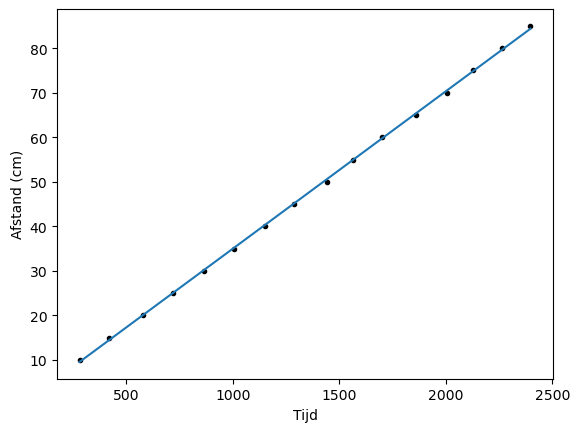

[ 0.03534313 -0.34576524]


In [3]:
# verwerk hier jullie kalibratiemetingen

distance = np.array([10,15,20, 25,30,35,40,45,50,55,60,65,70,75,80,85])  
time = np.array([280,418, 580, 720,863,1005,1151,1287,1440,1563,1700,1860,2005,2128,2263,2397]) 

def fit_function(time, a, b):
    return a * time + b
val, cov = curve_fit(fit_function, time, distance )
t_fit = np.linspace(min(time),max(time),100)
s_fit = fit_function(t_fit,*val)

plt.figure()
plt.xlabel('Tijd')
plt.ylabel('Afstand (cm)')
plt.plot(time, distance, 'k.')
plt.plot(t_fit, s_fit)
plt.show()

print(val)

## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
          xs         ys         xr         yr          R
0   0.000000  38.866856   0.000000  29.150142  49.263739
1   0.000000  29.150142   0.000000  19.433428  48.583569
2  38.866856   0.000000  29.150142   0.000000  46.348725
3  29.150142   0.000000  19.433428   0.000000  46.154391


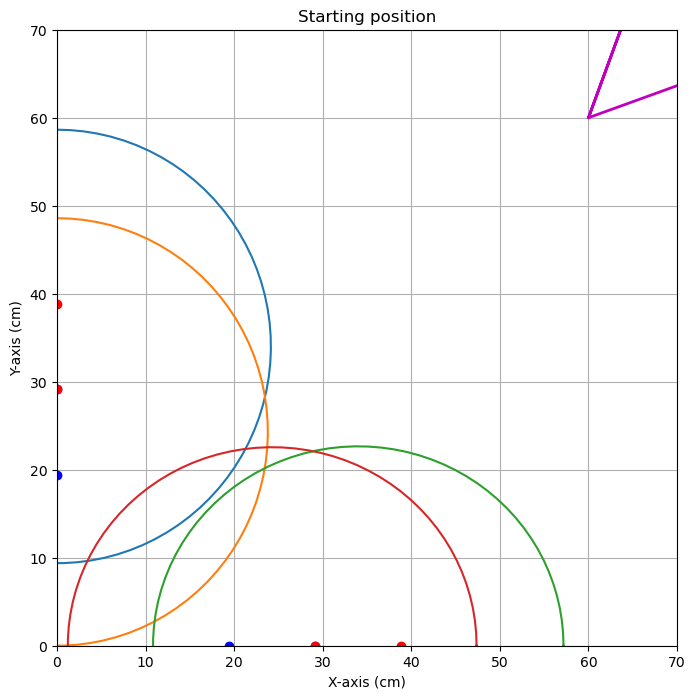


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=95.124


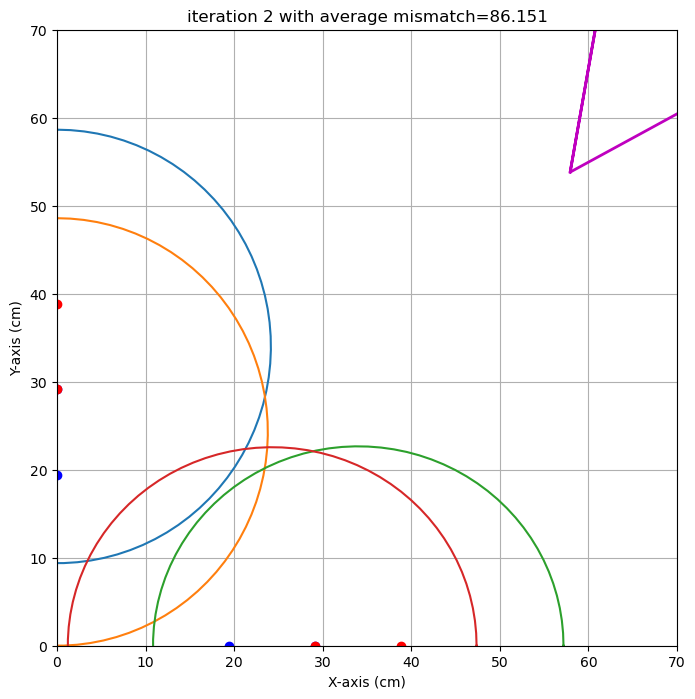

end iteration 2 with average mismatch=86.151


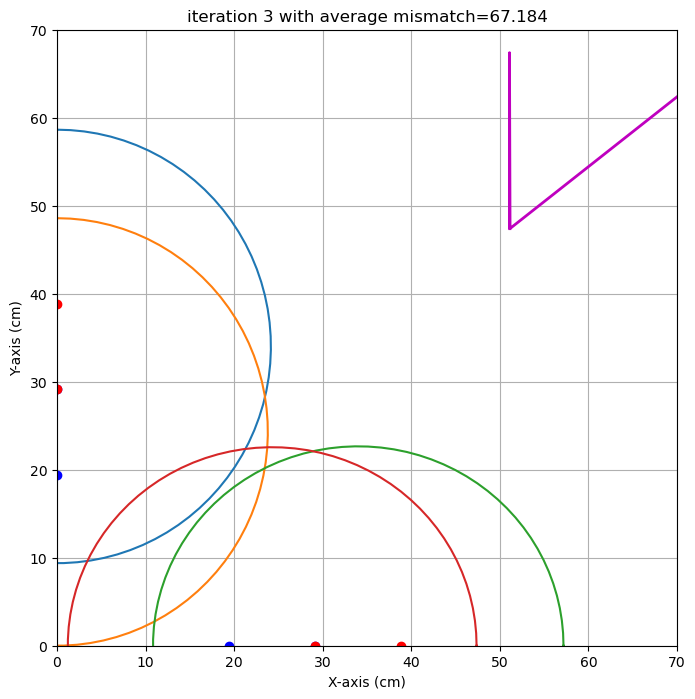

end iteration 3 with average mismatch=67.184


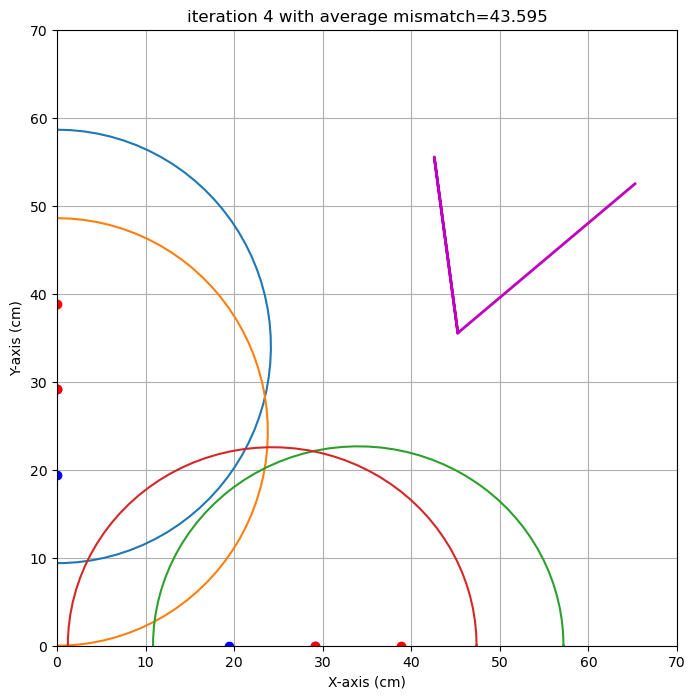

end iteration 4 with average mismatch=43.595


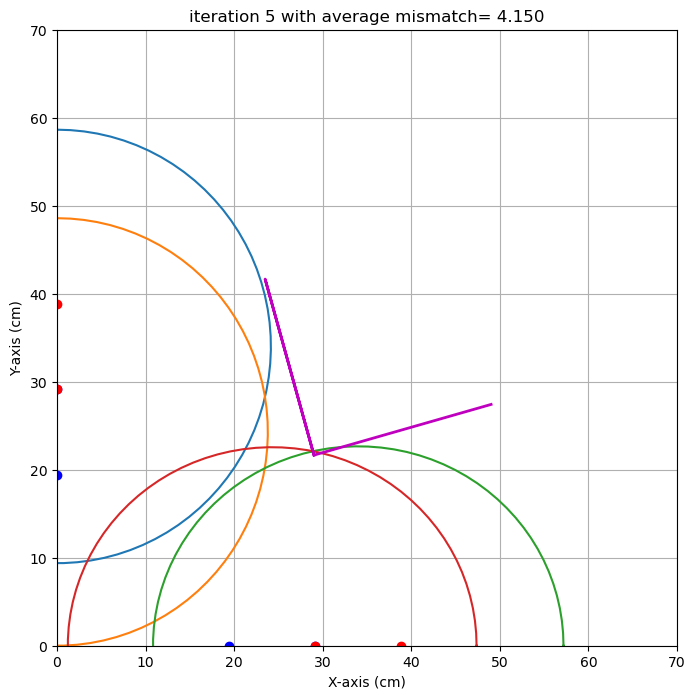

end iteration 5 with average mismatch= 4.150


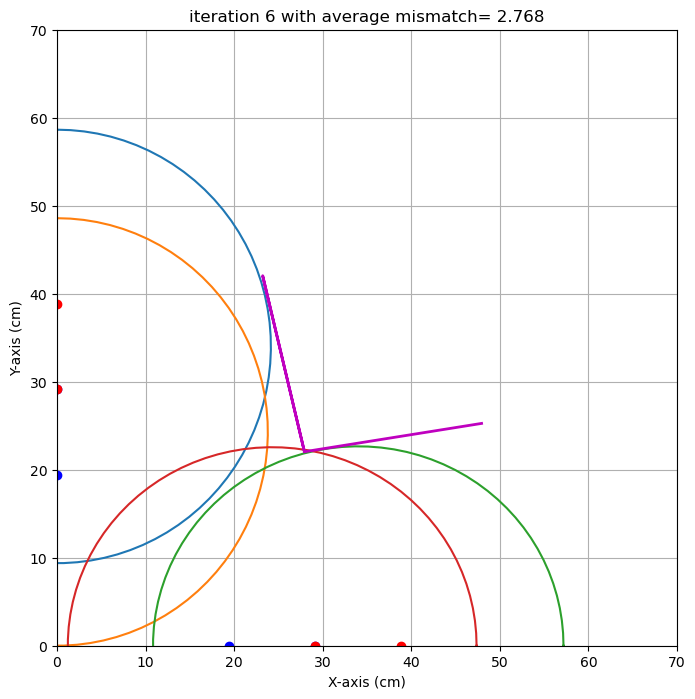

end iteration 6 with average mismatch= 2.768


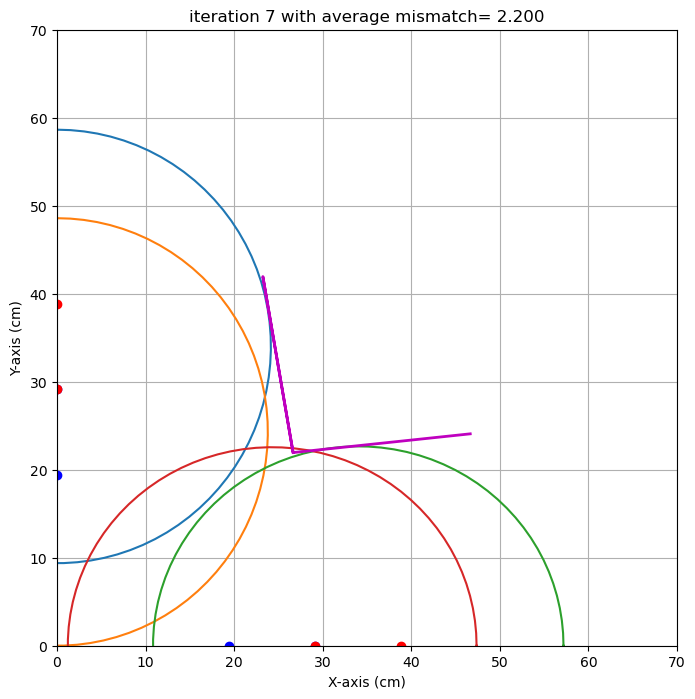

end iteration 7 with average mismatch= 2.200


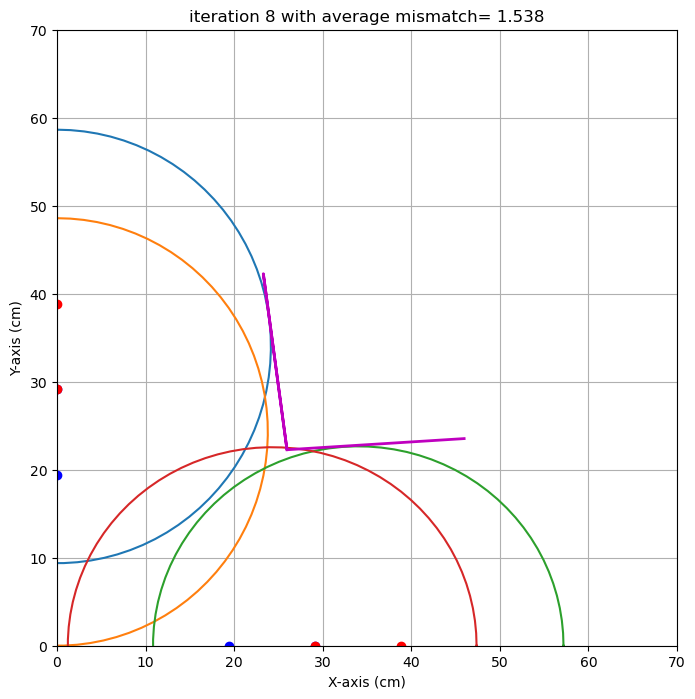

end iteration 8 with average mismatch= 1.538


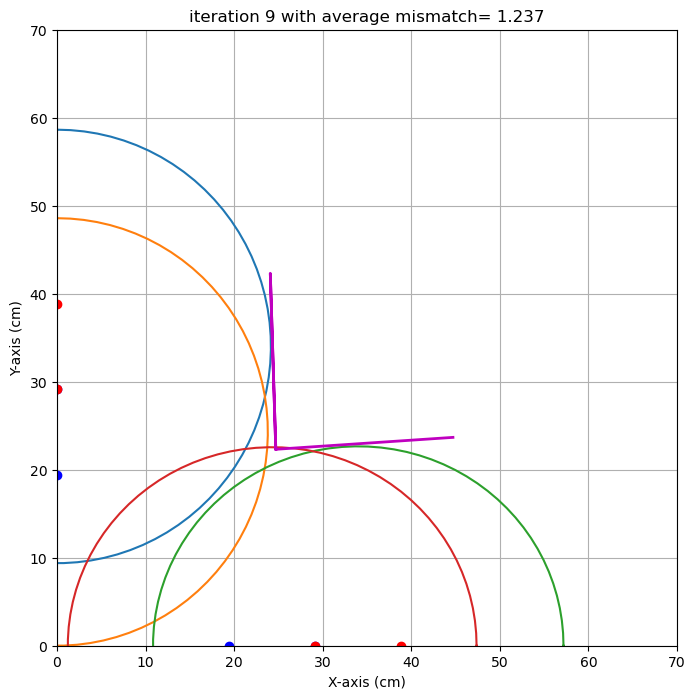

end iteration 9 with average mismatch= 1.237


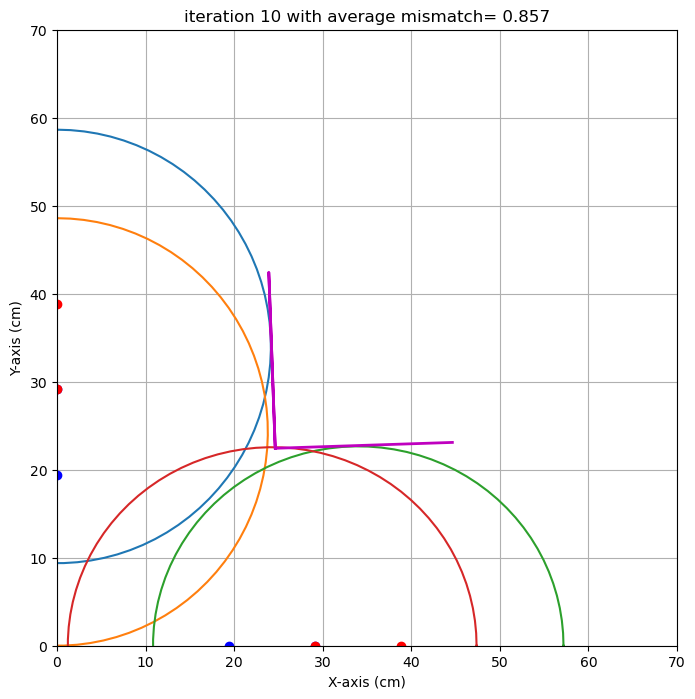

end iteration 10 with average mismatch= 0.857


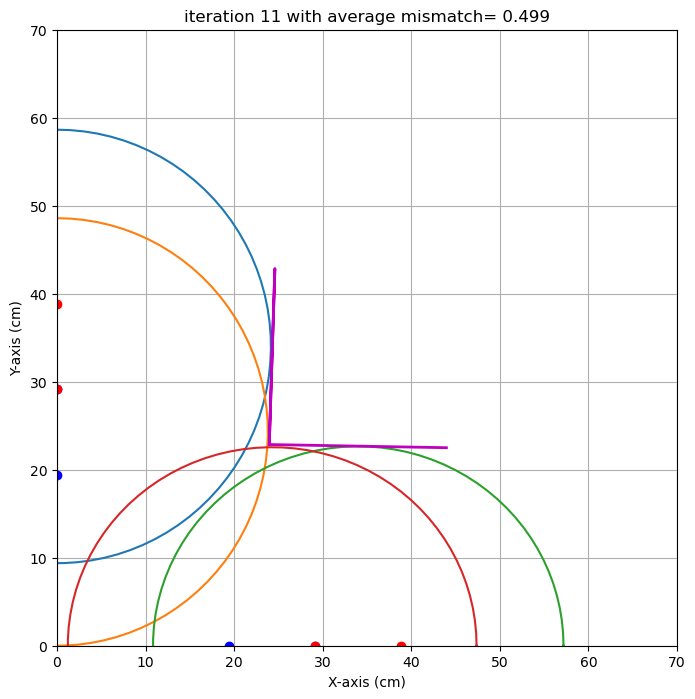

end iteration 11 with average mismatch= 0.499
end iteration 12 with average mismatch= 0.495


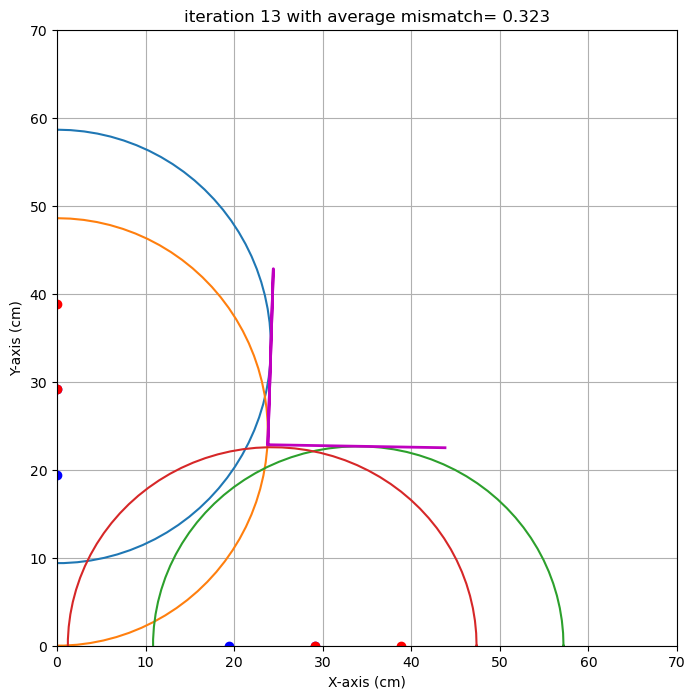

end iteration 13 with average mismatch= 0.323
end iteration 14 with average mismatch= 0.315
end iteration 15 with average mismatch= 0.315
end iteration 16 with average mismatch= 0.315
end iteration 17 with average mismatch= 0.315
end iteration 18 with average mismatch= 0.315
end iteration 19 with average mismatch= 0.315
end iteration 20 with average mismatch= 0.315
end iteration 21 with average mismatch= 0.315
end iteration 22 with average mismatch= 0.315
end iteration 23 with average mismatch= 0.315
end iteration 24 with average mismatch= 0.315
end iteration 25 with average mismatch= 0.288
end iteration 26 with average mismatch= 0.277
end iteration 27 with average mismatch= 0.270
end iteration 28 with average mismatch= 0.269
end iteration 29 with average mismatch= 0.269
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.269
#############

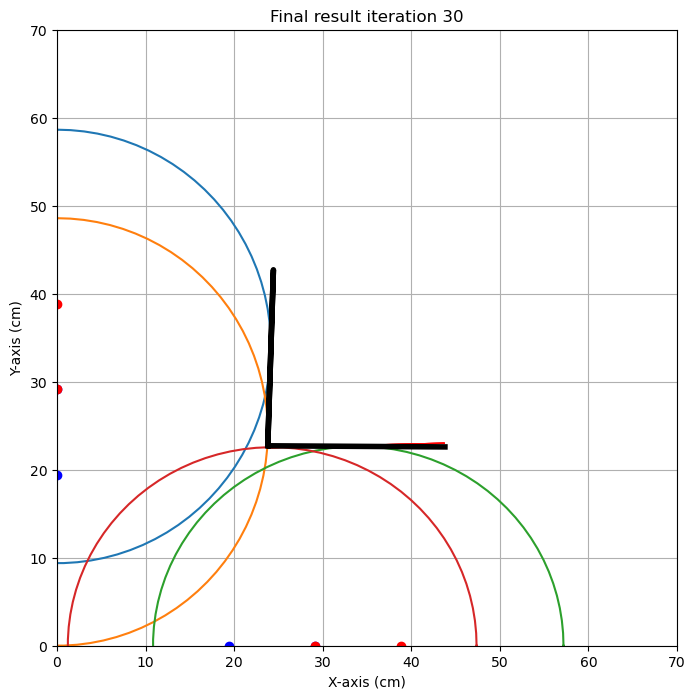

In [4]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

                
dataSanityCheck = 0.0343/0.0353*pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,50.7],
    [0,30,0,20,50.0],
    #[0,10,0,20,190.0],
    [40,0,30,0,47.7],
    [30,0,20,0,47.5],
    #[10,0,20,0,180.0],
    #[10,0,0,10,190.0]    
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [5]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 23.8 cm met een standaardafwijking van 0.1 cm 
y0: 22.7 cm met een standaardafwijking van 0.2 cm 
alpha: -0.4 graden met een standaardafwijking van 1.8 graad 
beta: 1.8 graden met een standaardafwijking van 0.8 graad 



## Opdracht 5: Iteratie 0

#### algoritme Annet
<img src="Algoritme_Annet.jpeg" width="400">

#### algoritme Daantje
<img src="Algoritme_Daantje.jpeg" width="400">

#### algoritme Annelinde
<img src="Algoritme_Annelinde.jpeg" width="400">

In [6]:
# Voeg hier eventueel code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 6: Test iteratie 0.

In [7]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0':41+2.95,  
           'y0':38+2.95,
           'alpha' : 33,
           'beta' : -26}
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={'Daantje' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,30,0,50,82],
    #[0,50,0,60,-],
    [0,20,0,30,91],
    #[30,0,50,0,-],
    #[10,0,30,0,-],
    [50,0,70,0,102],
    [55,0,65,0,171],
    ]),
        'Annet' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[29,0,36,0,-],
    [54,0,61,0,190],
   #[0,45,0,55,-],
   #[0,50,0,60,-],
   #geeft verder geen metingen doordat de sensoren te dicht bij elkaar staan voor de hoek van het karton
    ])
}

In [8]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0':41+2.95,  
           'y0':38+2.95,
           'alpha' : 33,
           'beta' : -26}
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={'Daantje' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,30,0,50,82],
    #[0,50,0,60,-],
    [0,20,0,30,91],
    #[30,0,50,0,-],
    #[10,0,30,0,-],
    [50,0,70,0,102],
    [55,0,65,0,171],
    ]),
        'Annet' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[29,0,36,0,-],
    [54,0,61,0,190],
   #[0,45,0,55,-],
   #[0,50,0,60,-],
   #geeft verder geen metingen doordat de sensoren te dicht bij elkaar staan voor de hoek van het karton
    ])
}

## Opdracht 7: Evaluatie.

Daantje
Running the imaging algorithm with the following data:
   xs  ys  xr  yr    R
0   0  30   0  50   82
1   0  20   0  30   91
2  50   0  70   0  102
3  55   0  65   0  171


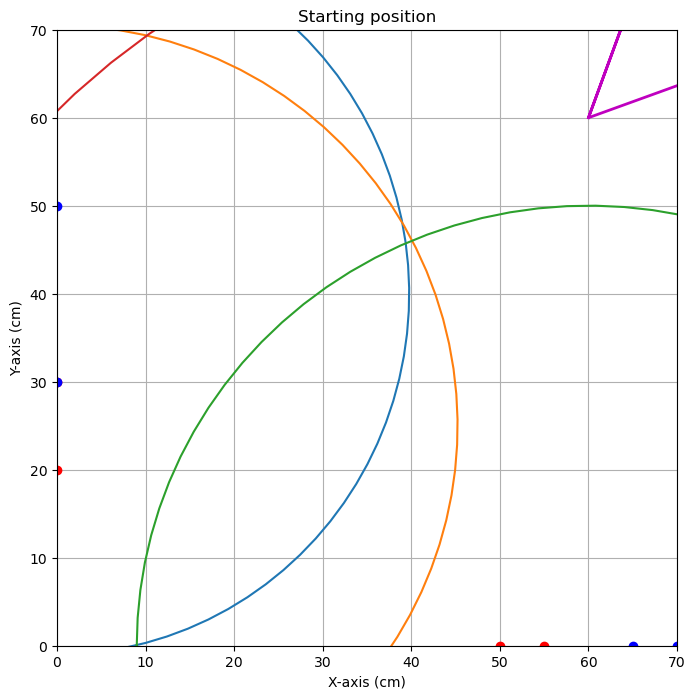


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=39.315


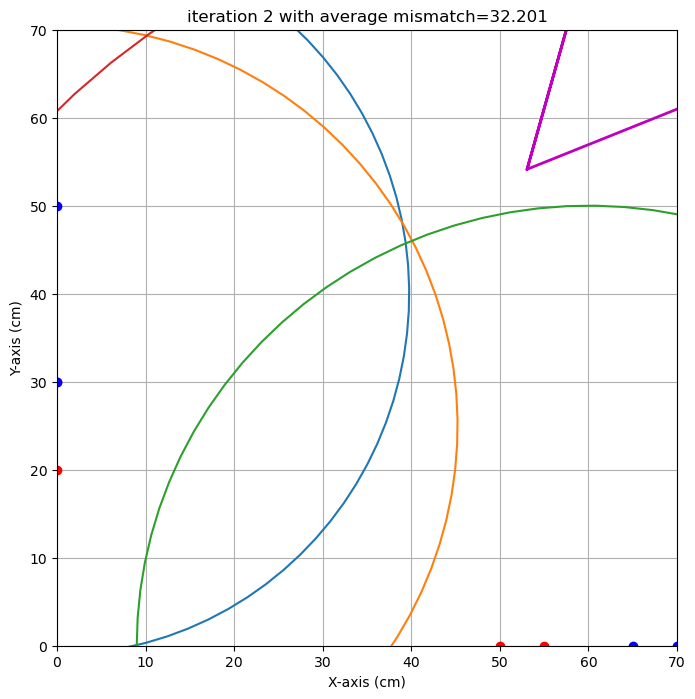

end iteration 2 with average mismatch=32.201


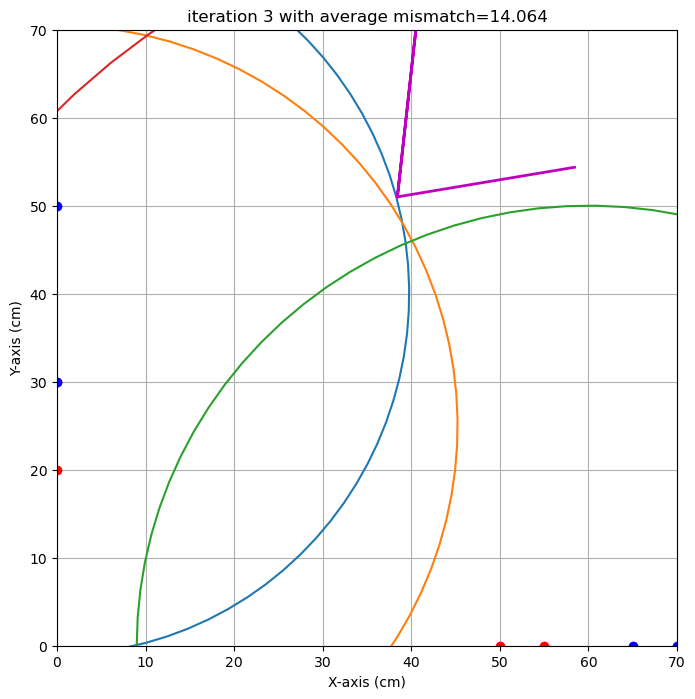

end iteration 3 with average mismatch=14.064


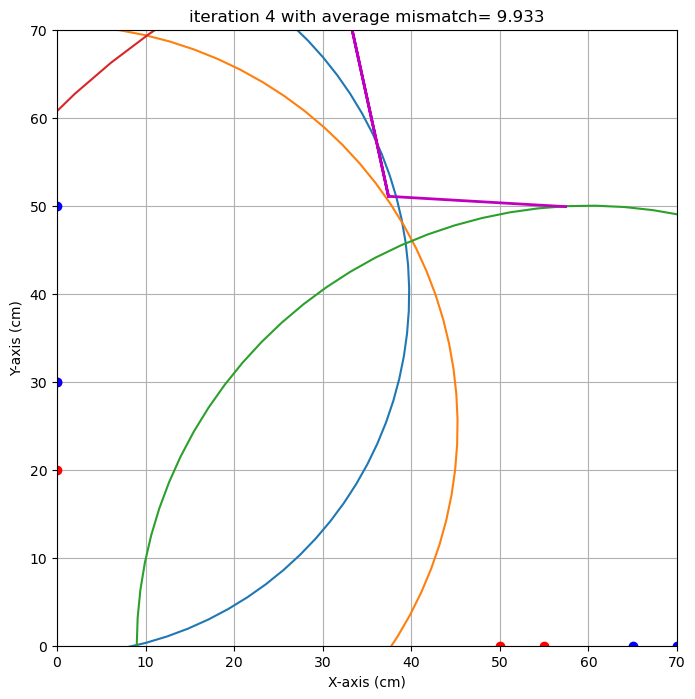

end iteration 4 with average mismatch= 9.933


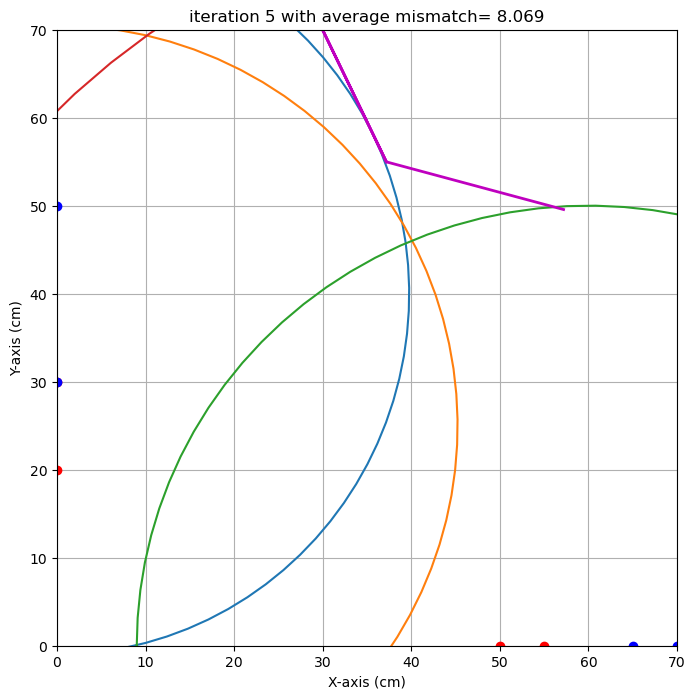

end iteration 5 with average mismatch= 8.069
end iteration 6 with average mismatch= 7.331
end iteration 7 with average mismatch= 7.286
end iteration 8 with average mismatch= 7.286
end iteration 9 with average mismatch= 7.286
end iteration 10 with average mismatch= 7.238
end iteration 11 with average mismatch= 7.141
end iteration 12 with average mismatch= 7.128
end iteration 13 with average mismatch= 7.058
end iteration 14 with average mismatch= 7.058
end iteration 15 with average mismatch= 7.058
end iteration 16 with average mismatch= 7.058
end iteration 17 with average mismatch= 7.058
end iteration 18 with average mismatch= 7.058
end iteration 19 with average mismatch= 7.045
end iteration 20 with average mismatch= 7.038
end iteration 21 with average mismatch= 7.038
end iteration 22 with average mismatch= 7.038
end iteration 23 with average mismatch= 7.038
end iteration 24 with average mismatch= 7.038
end iteration 25 with average mismatch= 7.038
end iteration 26 with average mismatch=

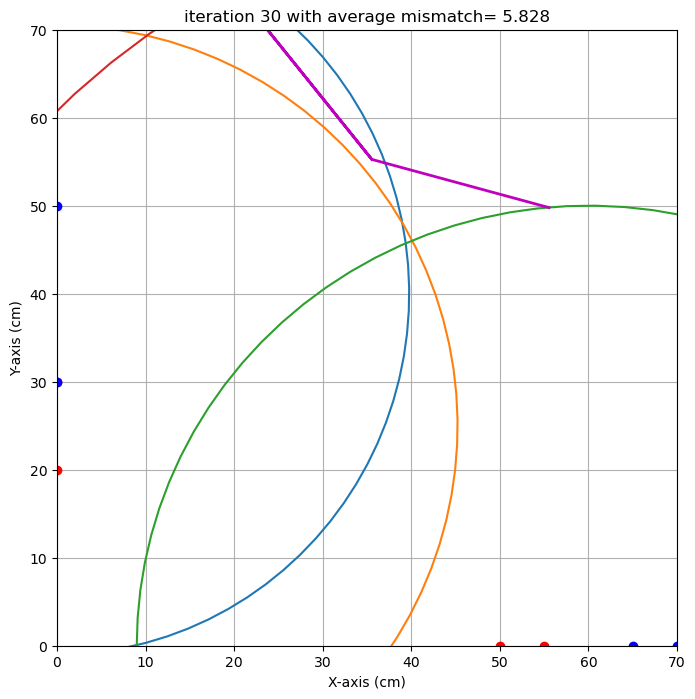

end iteration 30 with average mismatch= 5.828
###############################################################################
end of iteration  30
Best alpha= -15.31 with uncertainty=   2.41
Best beta = -38.65 with uncertainty=   5.53
Best x0   =  35.54 with uncertainty=   1.63
Best y0   =  55.26 with uncertainty=   0.69
###############################################################################


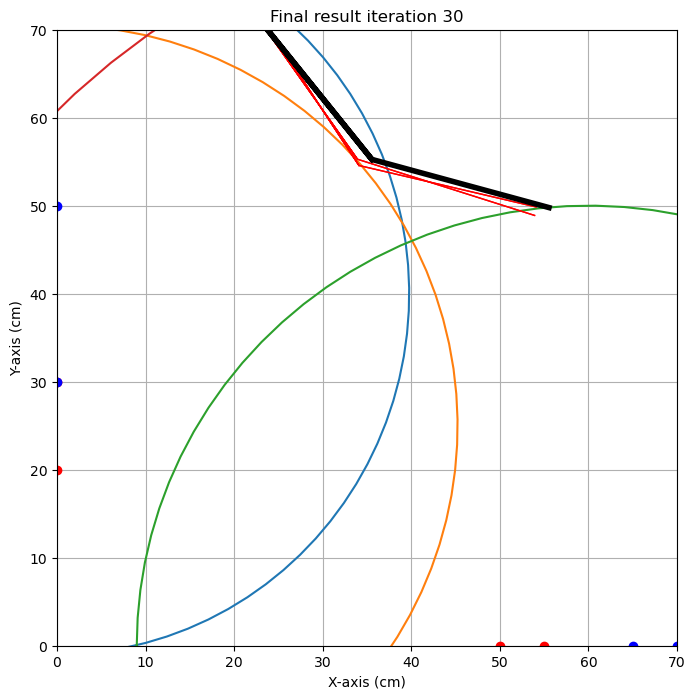

{'alpha': -15.30912562179757, 'alpha_eps': 2.4050683741337053, 'beta': -38.653440803265404, 'beta_eps': 5.526625980903503, 'x0': 35.544631691599186, 'x0_eps': 1.6271122046344288, 'y0': 55.26284532348737, 'y0_eps': 0.6905213856833825}
Annet
Running the imaging algorithm with the following data:
   xs  ys  xr  yr    R
0  54   0  61   0  190


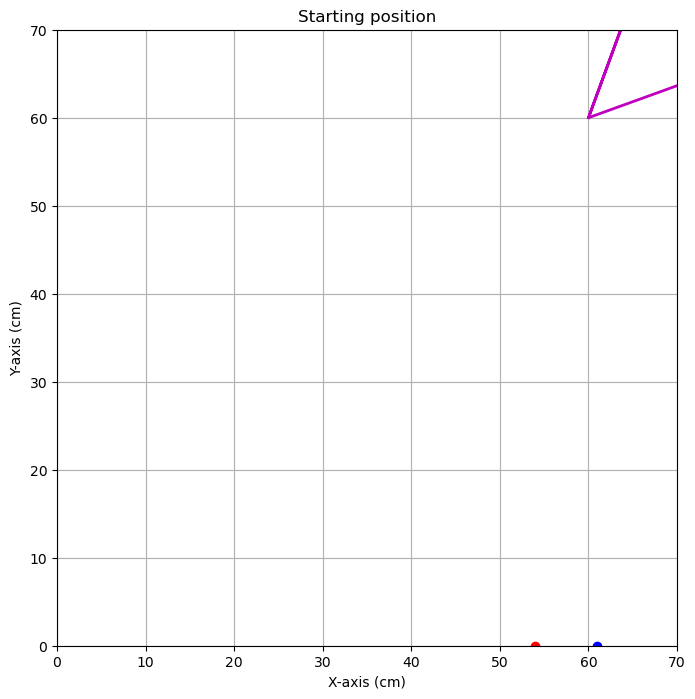


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=36.362


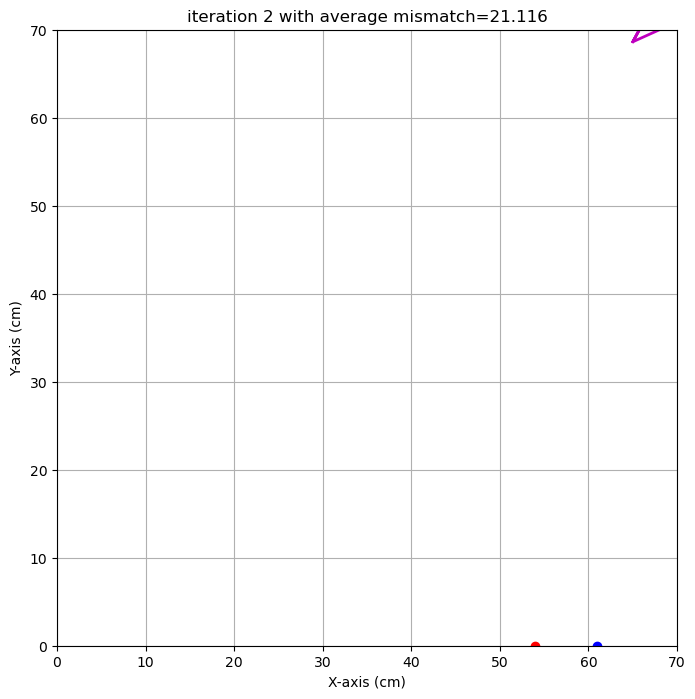

end iteration 2 with average mismatch=21.116


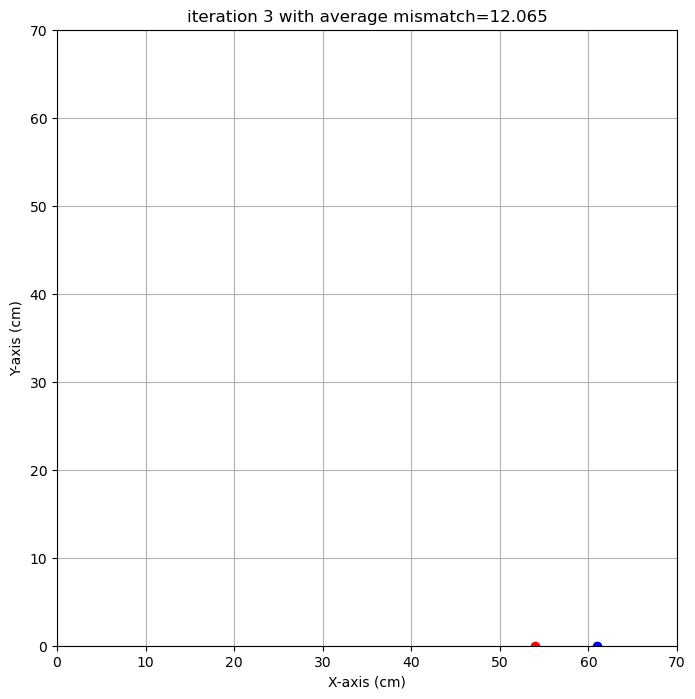

end iteration 3 with average mismatch=12.065
end iteration 4 with average mismatch=11.975
end iteration 5 with average mismatch=11.860
end iteration 6 with average mismatch=11.740
end iteration 7 with average mismatch=11.618
end iteration 8 with average mismatch=11.615
end iteration 9 with average mismatch=11.428
end iteration 10 with average mismatch=11.400
end iteration 11 with average mismatch=11.358
end iteration 12 with average mismatch=11.350
end iteration 13 with average mismatch=11.305
end iteration 14 with average mismatch=11.249
end iteration 15 with average mismatch=11.210
end iteration 16 with average mismatch=11.210
end iteration 17 with average mismatch=11.210
end iteration 18 with average mismatch=11.165
end iteration 19 with average mismatch=10.685
end iteration 20 with average mismatch=10.261
end iteration 21 with average mismatch= 9.717


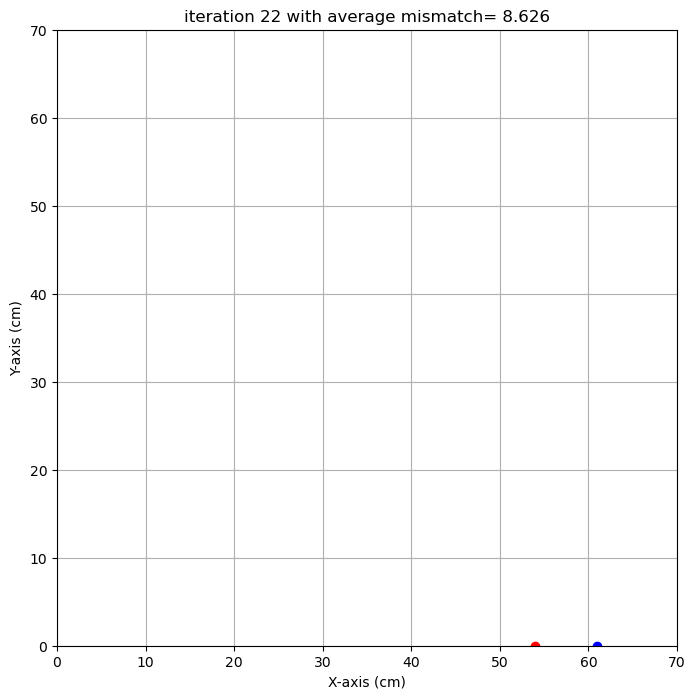

end iteration 22 with average mismatch= 8.626
end iteration 23 with average mismatch= 7.941


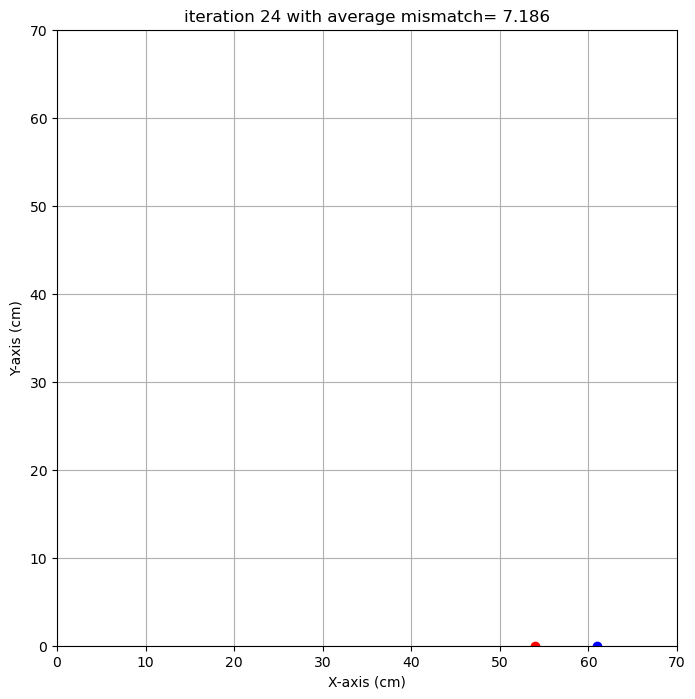

end iteration 24 with average mismatch= 7.186


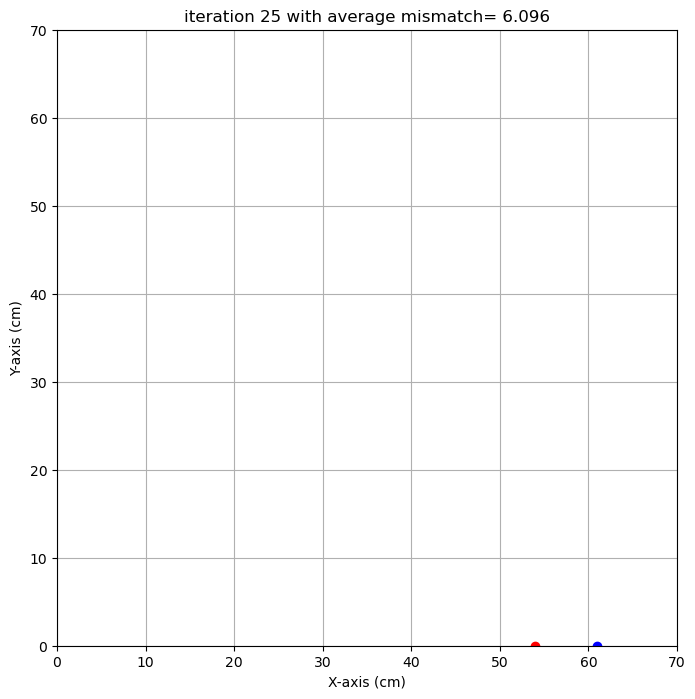

end iteration 25 with average mismatch= 6.096


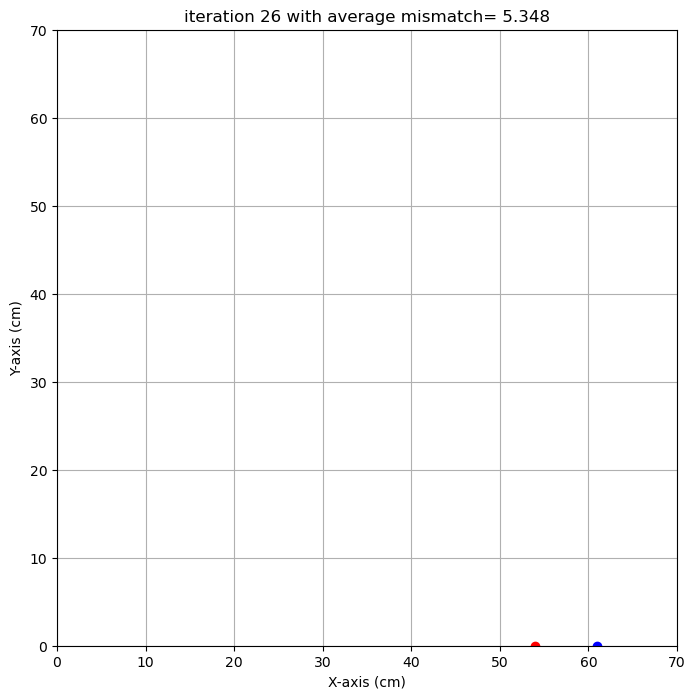

end iteration 26 with average mismatch= 5.348


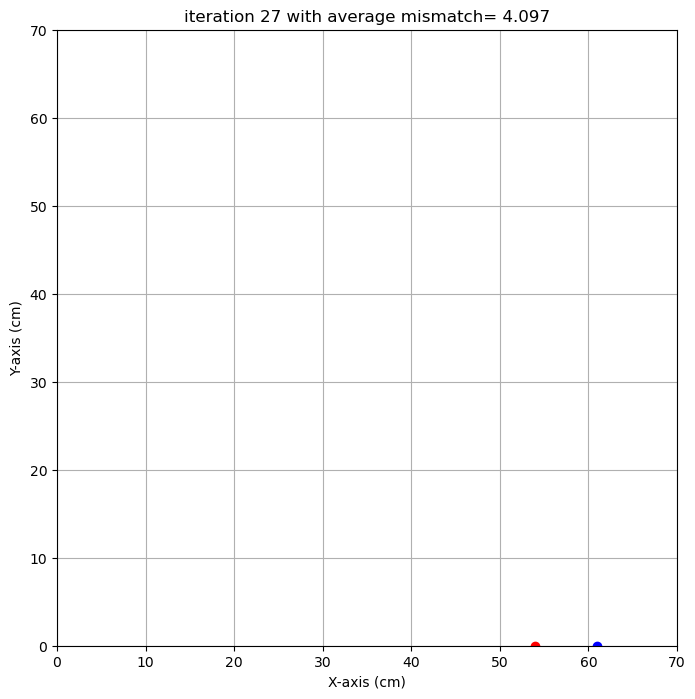

end iteration 27 with average mismatch= 4.097


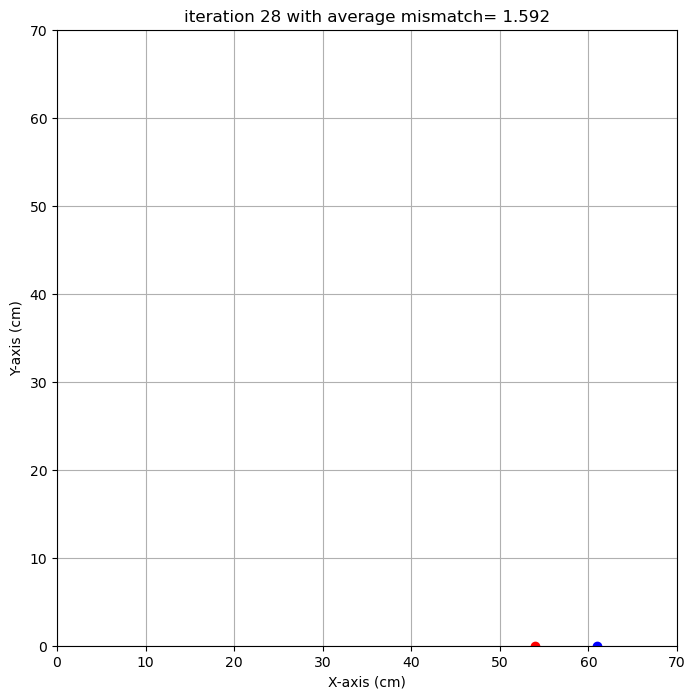

end iteration 28 with average mismatch= 1.592


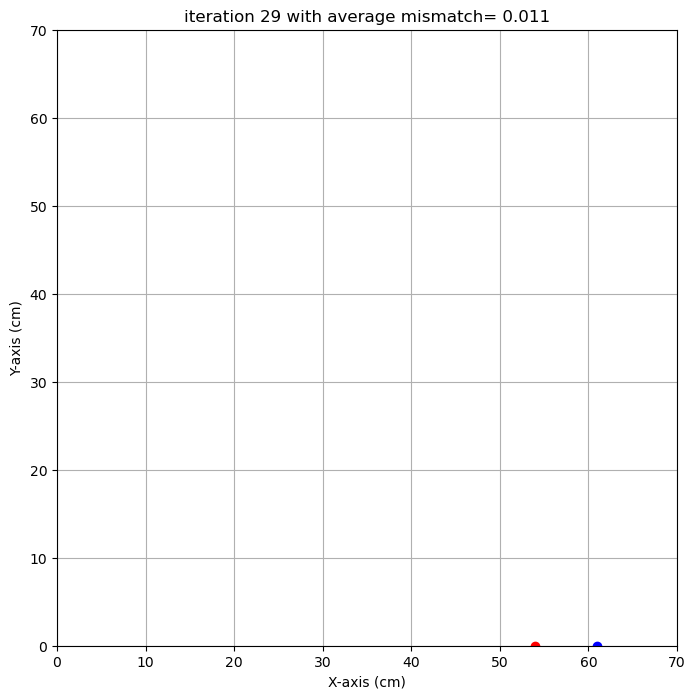

end iteration 29 with average mismatch= 0.011
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.011
###############################################################################
end of iteration  30
Best alpha=  41.15 with uncertainty=  14.87
Best beta = -39.97 with uncertainty=   7.92
Best x0   = 136.23 with uncertainty=   4.97
Best y0   =  53.91 with uncertainty=   4.99
###############################################################################


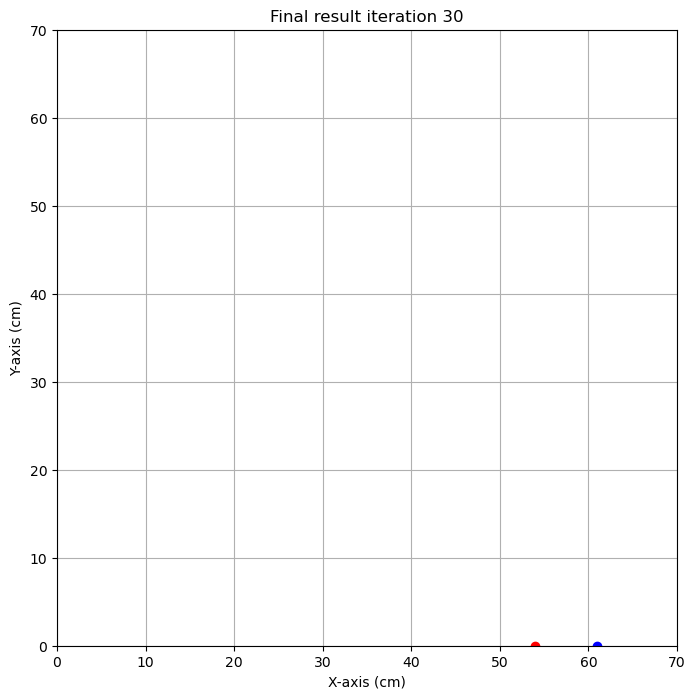

{'alpha': 41.15129806309827, 'alpha_eps': 14.872362037276769, 'beta': -39.96890743189894, 'beta_eps': 7.920612963605116, 'x0': 136.23345756841783, 'x0_eps': 4.967876206132701, 'y0': 53.91313549558683, 'y0_eps': 4.992979168696607}


In [9]:
# Hier runnen we het imaging algoritme:
resultaat = dict()
studentNames = ['Daantje', 'Annet']
for studentName in studentNames:
    print(studentName)
    resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
    print(resultaat[studentName])

In [10]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for studentName in studentNames:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName,
                     x0Target=targets['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))

Daantje 
x0 target is : 44.0. Gevonden waarde: 35.5 cm met een standaardafwijking van 1.6 cm 
y0 target is : 41.0. Gevonden waarde: 55.3 cm met een standaardafwijking van 0.7 cm 
alpha target is : 33.0. Gevonden waarde: -15.3 graden met een standaardafwijking van 2.4 graad 
beta target is : -26.0. Gevonden waarde: -38.7 graden met een standaardafwijking van 5.5 graad 

Annet 
x0 target is : 44.0. Gevonden waarde: 136.2 cm met een standaardafwijking van 5.0 cm 
y0 target is : 41.0. Gevonden waarde: 53.9 cm met een standaardafwijking van 5.0 cm 
alpha target is : 33.0. Gevonden waarde: 41.2 graden met een standaardafwijking van 14.9 graad 
beta target is : -26.0. Gevonden waarde: -40.0 graden met een standaardafwijking van 7.9 graad 



## Opdracht 8: Iteratie1+.VERVANG DEZE TEKST DOOR DE TIJD WANNEER JE AAN DEZE ITERATIE BEGINT.
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Door de hoek in het karton kwamen we er achter dat het uitsluiten van regio's niet goed werkt. Het karton kan namelijk wel in een regio staan, maar niet gezien worden. Daarom houden we de bron nu constant in het midden en verschuiven de bron over een as totdat we 2 metingen op die as hebben. Na proberen gaf ook dit vaak geen metingen op een as.

De volgende iteratie was om zowel de bron als de ontvanger te verschuiven van buiten naar binnen. Bij een goede meting verschuiven we zowel de bron als ontvanger 5 cm naar links of rechts. Dit hebben we hieronder bij locatie 2 gedaan.

Figuur: ![Alt](iteratie_1.jpeg)


## Opdracht 9: Iteratie 1 en 2 + meeting en test

locatie 1
Running the imaging algorithm with the following data:
   xs  ys  xr   yr      R
0  45   0  60    0  104.0
1  40   0  70  109    NaN
2   0  45   0   20   67.3
3   0  45   0   30   62.0


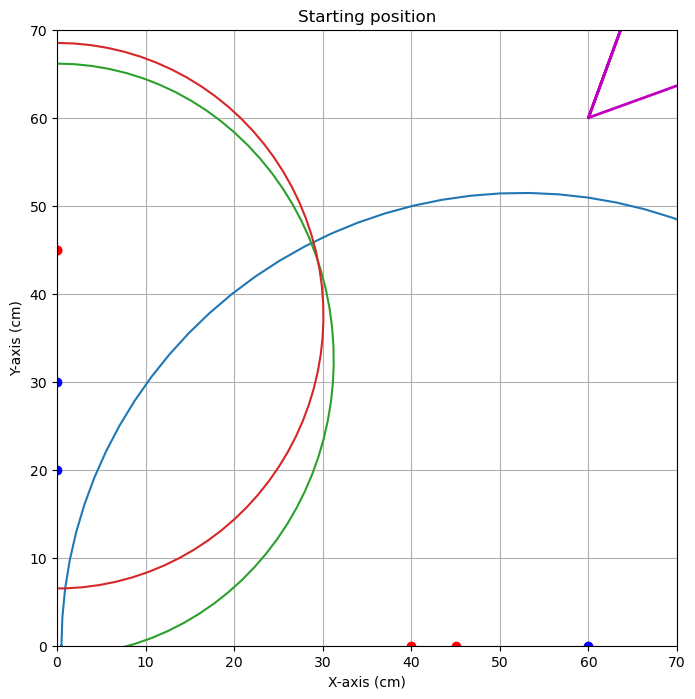


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=   nan
end iteration 2 with average mismatch=   nan
end iteration 3 with average mismatch=   nan
end iteration 4 with average mismatch=   nan
end iteration 5 with average mismatch=   nan
end iteration 6 with average mismatch=   nan
end iteration 7 with average mismatch=   nan
end iteration 8 with average mismatch=   nan
end iteration 9 with average mismatch=   nan
end iteration 10 with average mismatch=   nan
end iteration 11 with average mismatch=   nan
end iteration 12 with average mismatch=   nan
end iteration 13 with average mismatch=   nan
end iteration 14 with average mismatch=   nan
end iteration 15 with average mismatch=   nan
end iteration 16 with average mismatch=   nan
end iteration 17 with average mismatch=   nan
end iteration 18 with average mismatch=   nan
end iteration 19 with average mismatch=   nan
end iteration 20 with average mismatch=   nan
end iteration 21 with ave

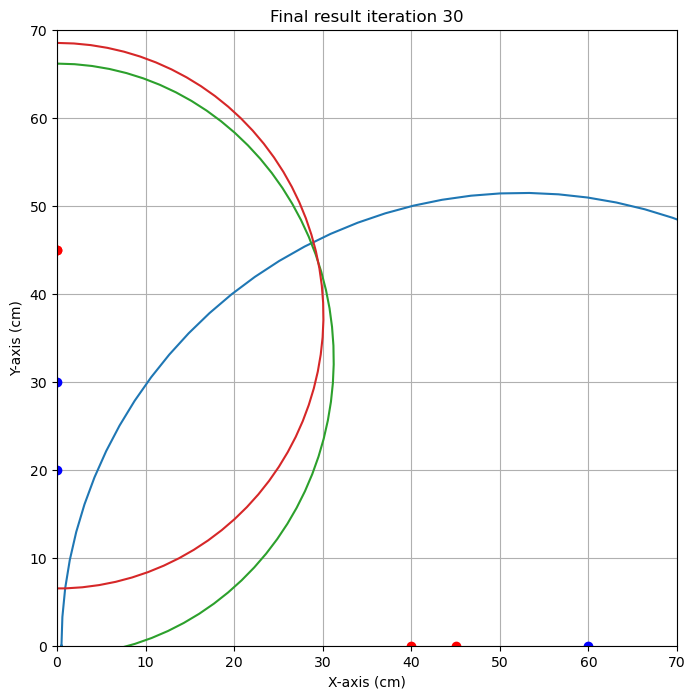

{'alpha': nan, 'alpha_eps': 0.0, 'beta': nan, 'beta_eps': 0.0, 'x0': nan, 'x0_eps': 0.0, 'y0': nan, 'y0_eps': 0.0}
locatie 2
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  30   0  50   0  80.0
1  35   0  55   0  72.8
2   0  15   0  65  78.1
3   0  10   0  60  79.0


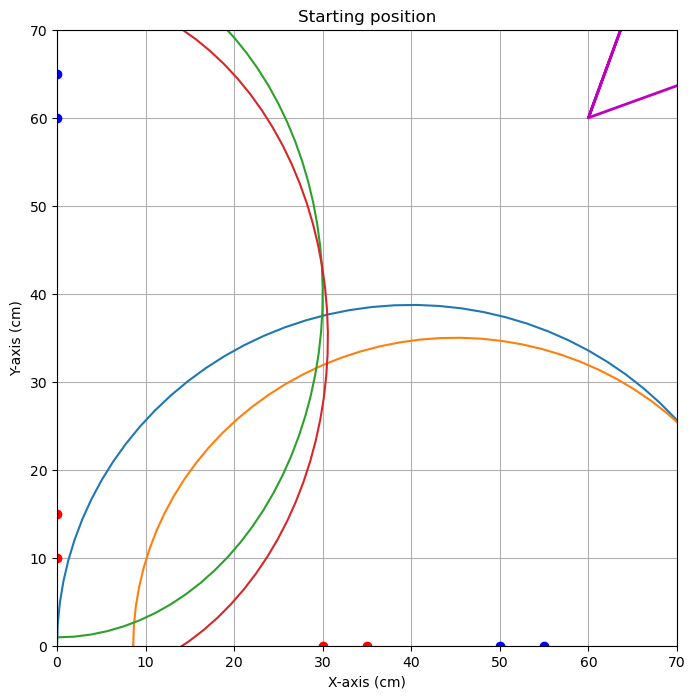


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=60.725


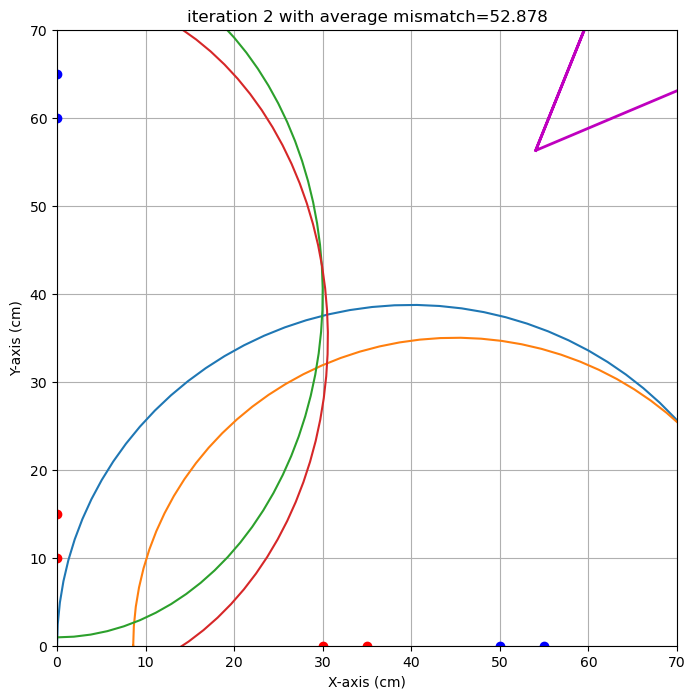

end iteration 2 with average mismatch=52.878


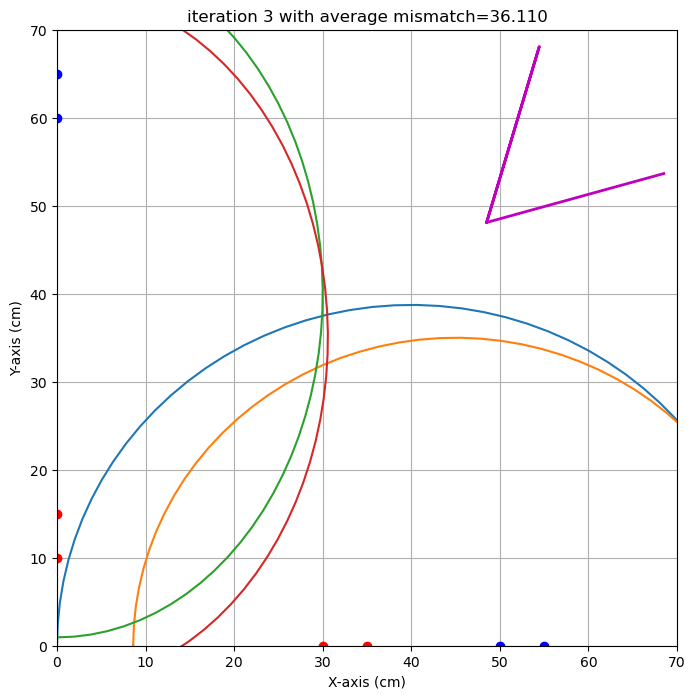

end iteration 3 with average mismatch=36.110


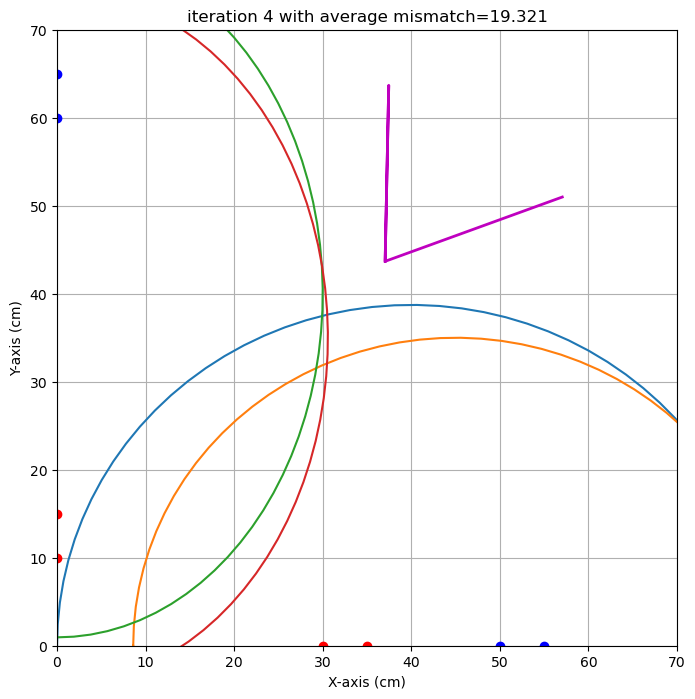

end iteration 4 with average mismatch=19.321


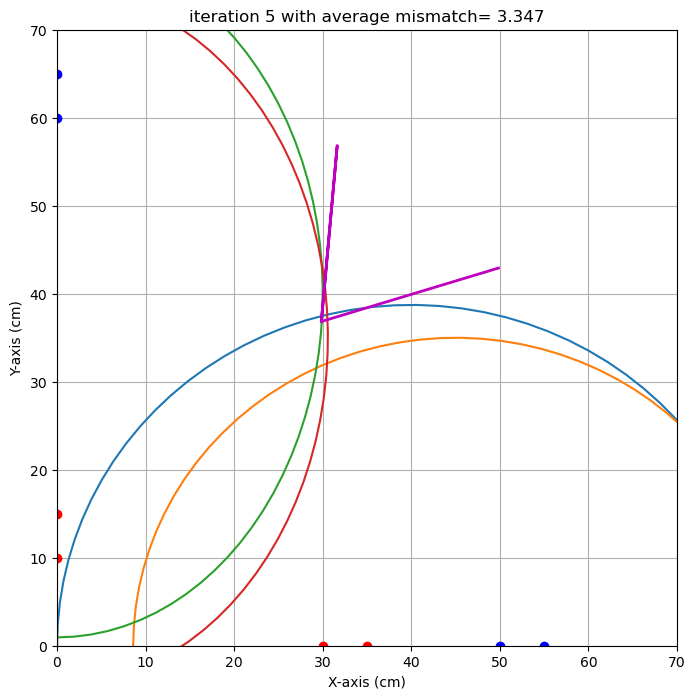

end iteration 5 with average mismatch= 3.347


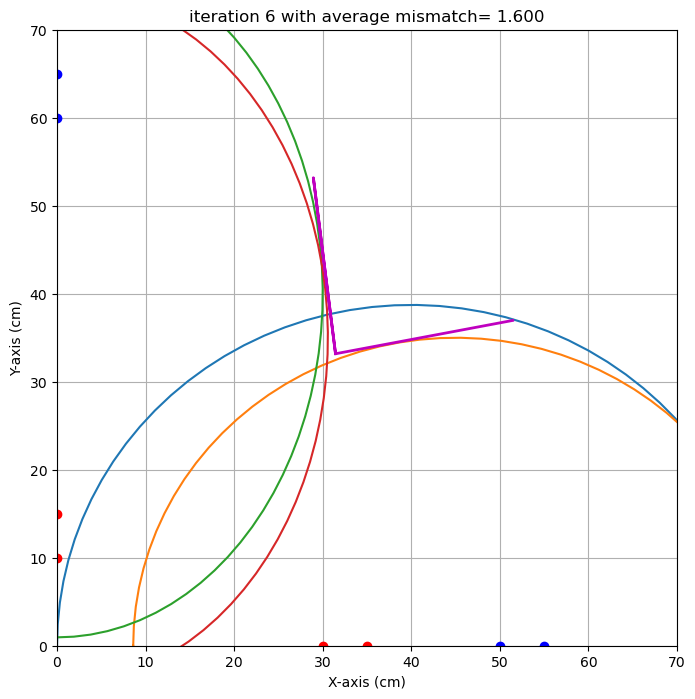

end iteration 6 with average mismatch= 1.600
end iteration 7 with average mismatch= 1.494
end iteration 8 with average mismatch= 1.478
end iteration 9 with average mismatch= 1.475
end iteration 10 with average mismatch= 1.475
end iteration 11 with average mismatch= 1.475
end iteration 12 with average mismatch= 1.475
end iteration 13 with average mismatch= 1.475
end iteration 14 with average mismatch= 1.449
end iteration 15 with average mismatch= 1.439
end iteration 16 with average mismatch= 1.436
end iteration 17 with average mismatch= 1.435
end iteration 18 with average mismatch= 1.435
end iteration 19 with average mismatch= 1.435
end iteration 20 with average mismatch= 1.435
end iteration 21 with average mismatch= 1.435
end iteration 22 with average mismatch= 1.435
end iteration 23 with average mismatch= 1.435
end iteration 24 with average mismatch= 1.435
end iteration 25 with average mismatch= 1.435
end iteration 26 with average mismatch= 1.435
end iteration 27 with average mismatch

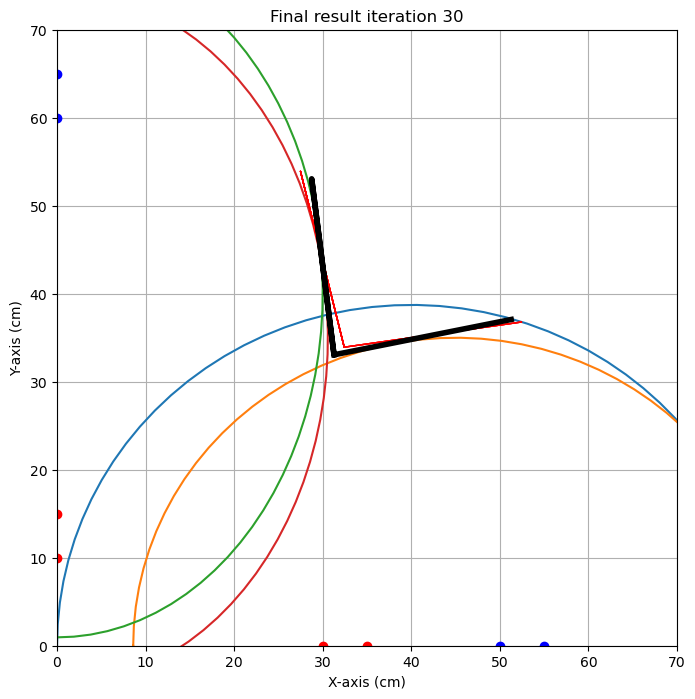

{'alpha': 11.340511544161895, 'alpha_eps': 3.208182780656527, 'beta': -7.194757195752167, 'beta_eps': 6.684720602090314, 'x0': 31.274538583025112, 'x0_eps': 1.151101819708792, 'y0': 33.059519597114345, 'y0_eps': 0.8643623985997735}
locatie 1 
x0 target is : 33.0. Gevonden waarde: nan cm met een standaardafwijking van 0.0 cm 
y0 target is : 40.5. Gevonden waarde: nan cm met een standaardafwijking van 0.0 cm 
alpha target is : 30.0. Gevonden waarde: nan graden met een standaardafwijking van 0.0 graad 
beta target is : -26.0. Gevonden waarde: nan graden met een standaardafwijking van 0.0 graad 

locatie 2 
x0 target is : 29.4. Gevonden waarde: 31.3 cm met een standaardafwijking van 1.2 cm 
y0 target is : 29.4. Gevonden waarde: 33.1 cm met een standaardafwijking van 0.9 cm 
alpha target is : 18.0. Gevonden waarde: 11.3 graden met een standaardafwijking van 3.2 graad 
beta target is : -5.0. Gevonden waarde: -7.2 graden met een standaardafwijking van 6.7 graad 



In [11]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0':30+2.95,  
                    'y0':37.5+2.95,
                    'alpha' : 30,
                    'beta' : -26},
           'locatie 2':{'x0':26.5+2.95,
                    'y0':26.5+2.95,
                    'alpha' :18 ,
                    'beta' : -5}
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[45,0,10,0,-],
    #[45,0,20,0,-],
    #[45,0,30,0,-],
    #[45,0,50,0,-],
    [45,0,60,0,104],
    [40,0,70,109],
    #[0,45,0,10,-],
    [0,45,0,20,67.3],
    [0,45,0,30,62.0]
    ]),
    #voor locatie 2 ITERATIE 2!!, zie uitleg hierboven
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[15,0,65,0,-],
    #[20,0,60,0,-],
    #[25,0,55,0,-],
    [30,0,50,0,80],
    [35,0,55,0,72.8],
    [0,15,0,65,78.1],
    [0,10,0,60,79]
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

Iteratie 3

De vorige iteratie met beide bronnen naar binnen verschuiven lijkt te werken. Om het resultaat nauwkeuriger te maken, doen we nu 3 goede metingen per as.

Figuur: ![Alt](iteratie_2.jpeg)


Iteratie 4: Meer metingen per kant voor betere nauwkeurigheid als er metingen over zijn

Figuur: ![Alt](iteratie_3.jpeg)

locatie 1
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  15   0  65   0  76.3
1  20   0  70   0  80.9
2  25   0  75   0  82.0
3   0  15   0  65  80.0
4   0  20   0  70  78.0
5   0  25   0  75  79.3


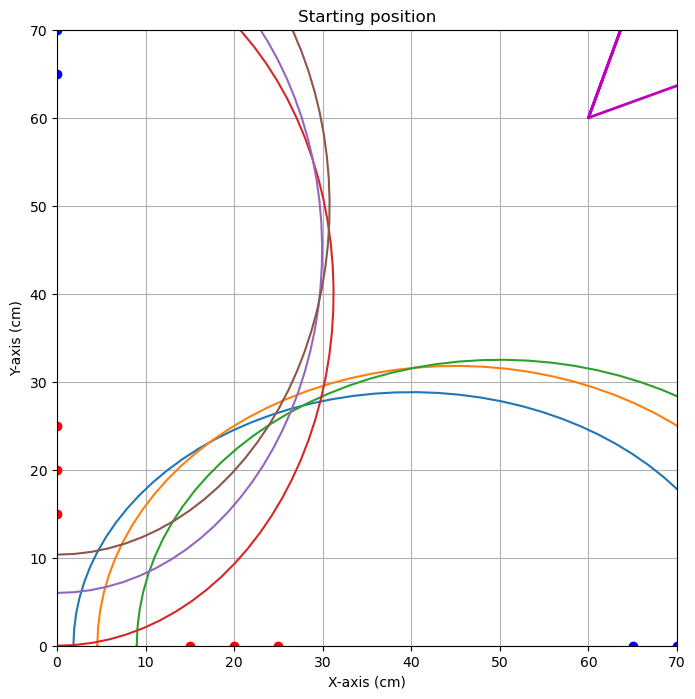


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=59.646


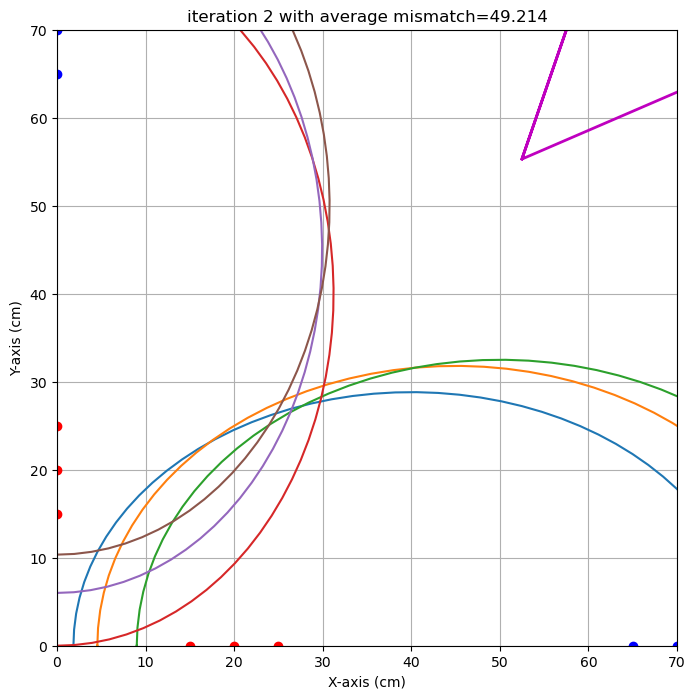

end iteration 2 with average mismatch=49.214


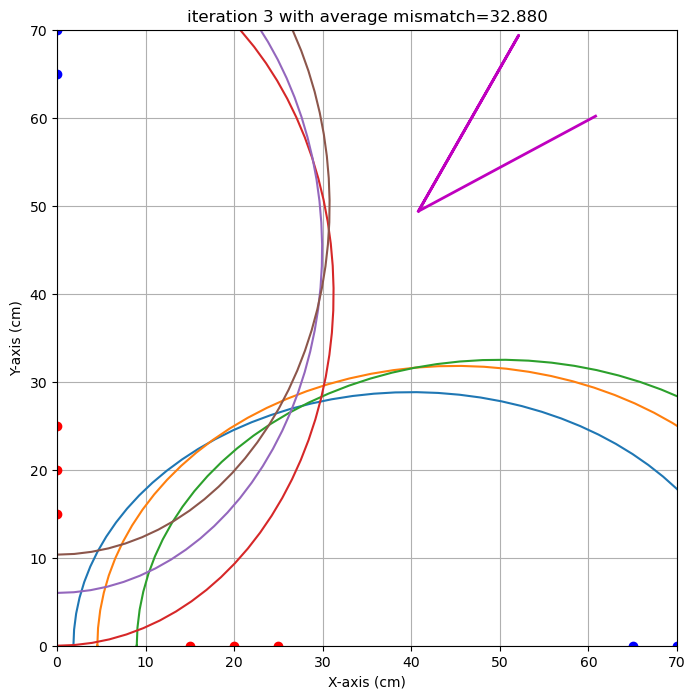

end iteration 3 with average mismatch=32.880


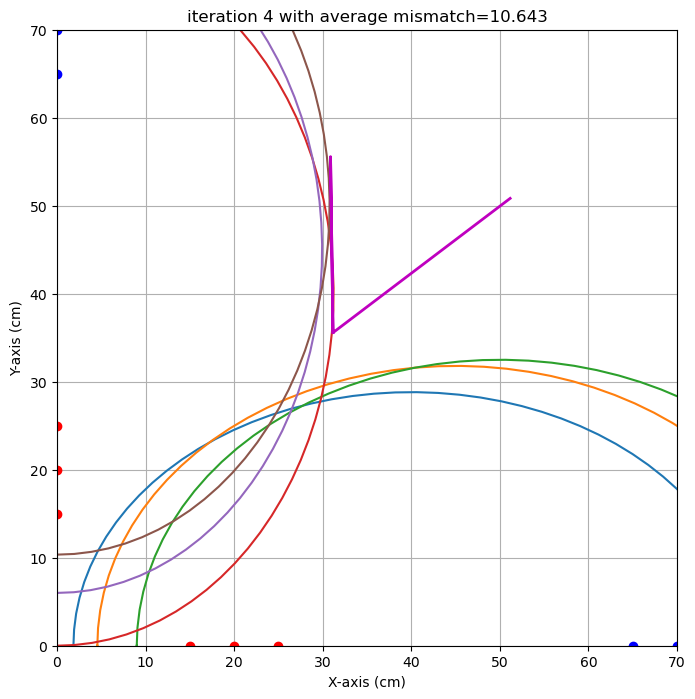

end iteration 4 with average mismatch=10.643


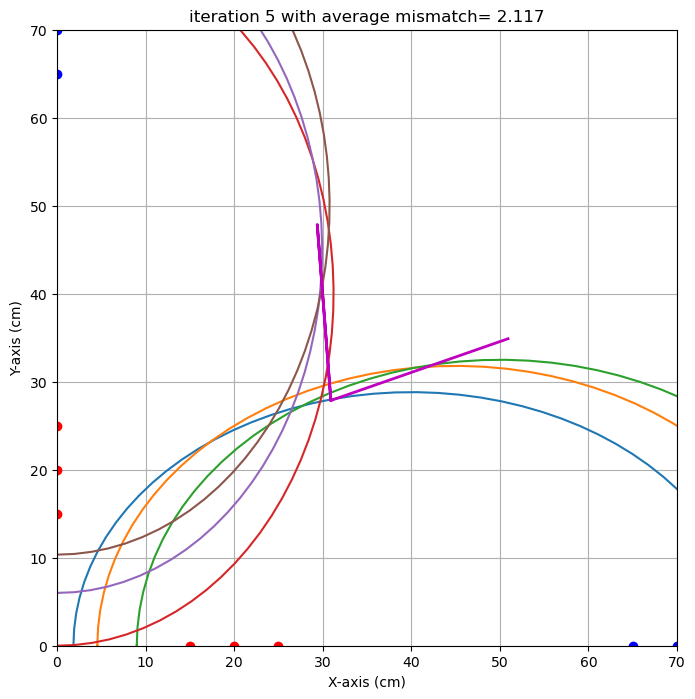

end iteration 5 with average mismatch= 2.117


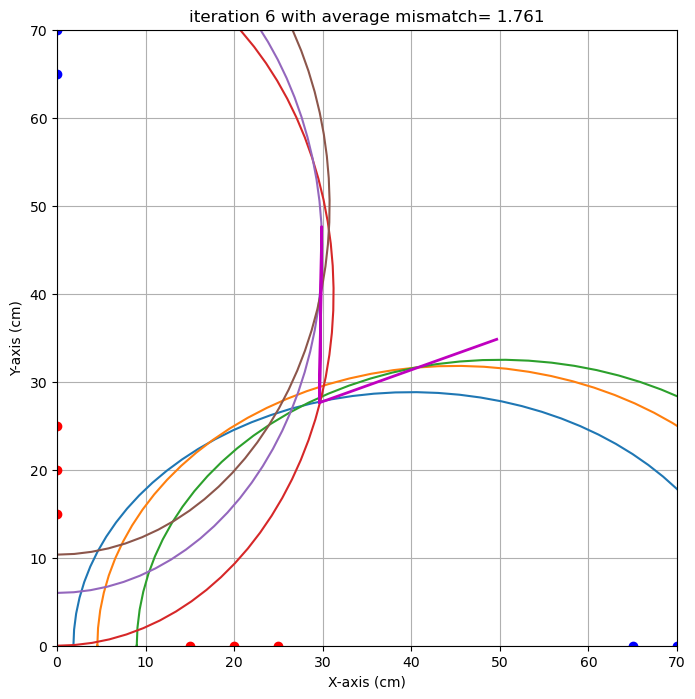

end iteration 6 with average mismatch= 1.761
end iteration 7 with average mismatch= 1.600


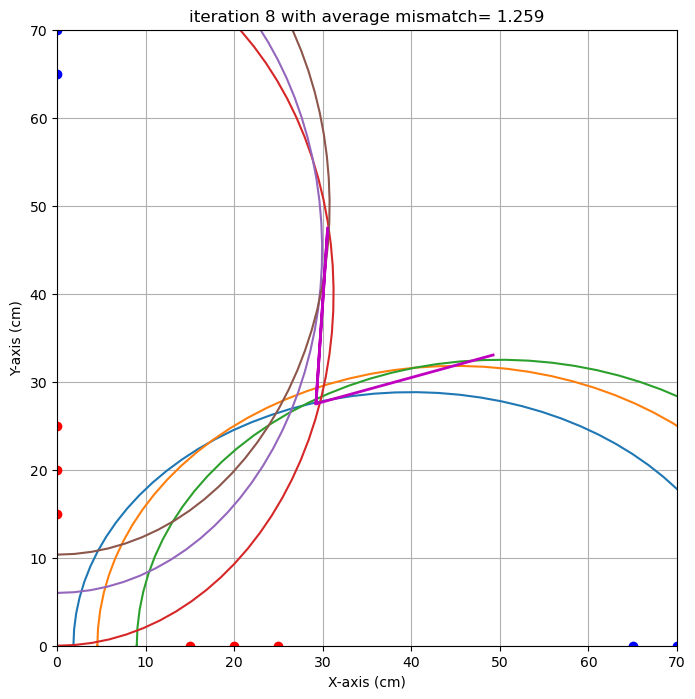

end iteration 8 with average mismatch= 1.259
end iteration 9 with average mismatch= 1.162
end iteration 10 with average mismatch= 1.074
end iteration 11 with average mismatch= 1.074
end iteration 12 with average mismatch= 1.074
end iteration 13 with average mismatch= 1.074
end iteration 14 with average mismatch= 1.074
end iteration 15 with average mismatch= 1.074
end iteration 16 with average mismatch= 1.074
end iteration 17 with average mismatch= 1.074
end iteration 18 with average mismatch= 1.074
end iteration 19 with average mismatch= 1.074
end iteration 20 with average mismatch= 1.074
end iteration 21 with average mismatch= 1.074
end iteration 22 with average mismatch= 1.074
end iteration 23 with average mismatch= 1.074
end iteration 24 with average mismatch= 1.074
end iteration 25 with average mismatch= 1.074
end iteration 26 with average mismatch= 1.074
end iteration 27 with average mismatch= 1.074
end iteration 28 with average mismatch= 1.074
end iteration 29 with average mismat

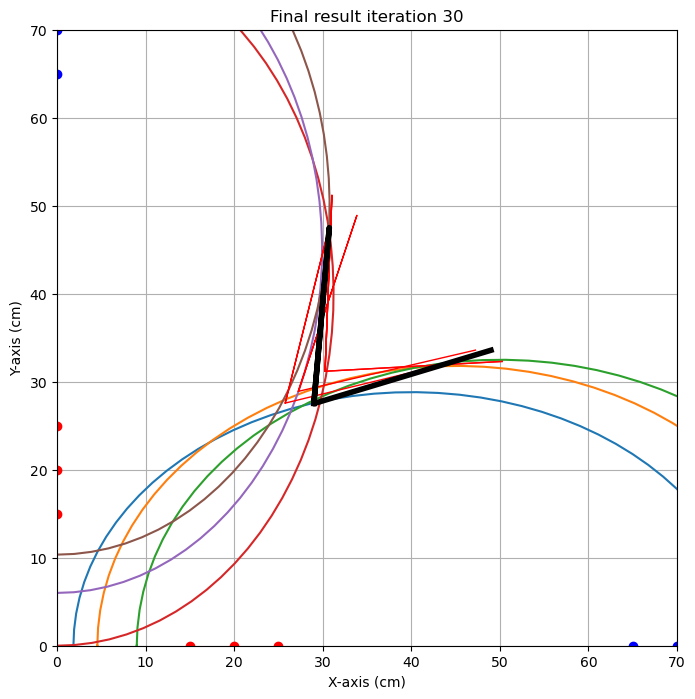

{'alpha': 16.855410095663682, 'alpha_eps': 13.664446248382694, 'beta': 4.993514509101456, 'beta_eps': 13.305994989724283, 'x0': 28.994374086483518, 'x0_eps': 3.232681677728806, 'y0': 27.518568174765576, 'y0_eps': 3.670996056226727}
locatie 2
Running the imaging algorithm with the following data:
      xs    ys    xr    yr     R
0   15.0  -2.5  65.0  -2.5  76.3
1   20.0  -2.5  70.0  -2.5  80.9
2   25.0  -2.5  75.0  -2.5  82.0
3   20.0  -2.5  60.0  -2.5  73.0
4   25.0  -2.5  65.0  -2.5  75.0
5   15.0  -2.5  55.0  -2.5  74.0
6   -2.5  15.0  -2.5  65.0  80.0
7   -2.5  20.0  -2.5  70.0  78.0
8   -2.5  25.0  -2.5  75.0  79.3
9   -2.5  20.0  -2.5  60.0  71.0
10  -2.5  25.0  -2.5  65.0  72.0


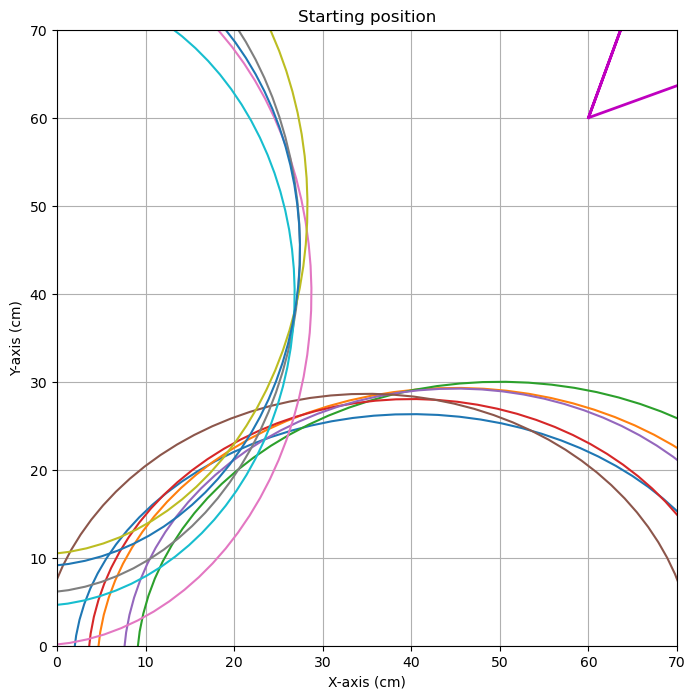


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=66.889


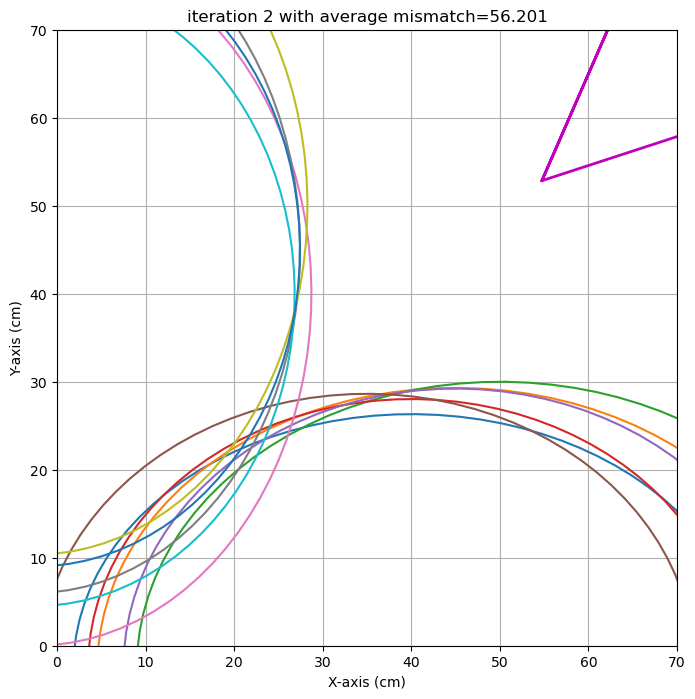

end iteration 2 with average mismatch=56.201


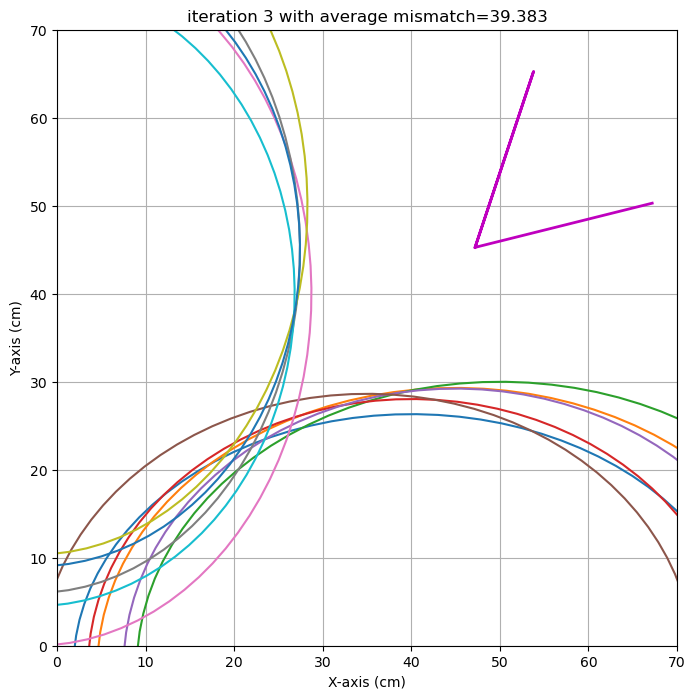

end iteration 3 with average mismatch=39.383


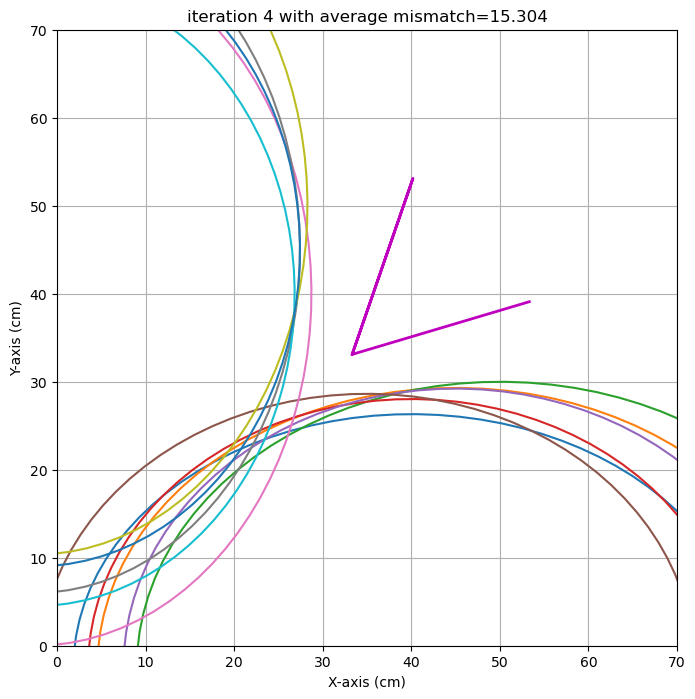

end iteration 4 with average mismatch=15.304


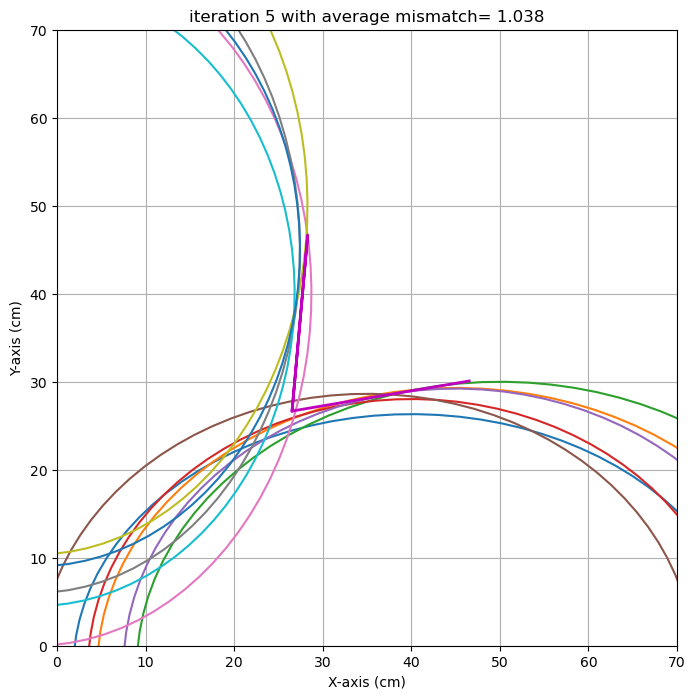

end iteration 5 with average mismatch= 1.038


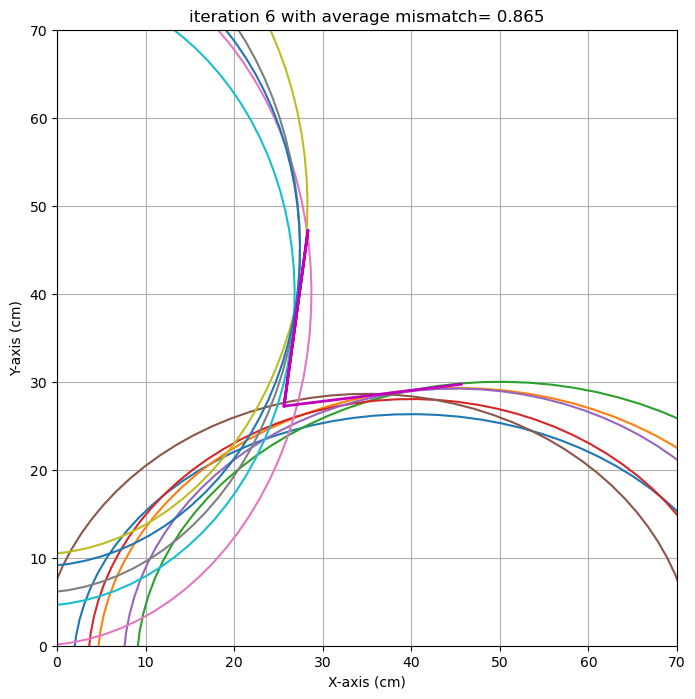

end iteration 6 with average mismatch= 0.865
end iteration 7 with average mismatch= 0.853
end iteration 8 with average mismatch= 0.847
end iteration 9 with average mismatch= 0.836
end iteration 10 with average mismatch= 0.805
end iteration 11 with average mismatch= 0.805
end iteration 12 with average mismatch= 0.805
end iteration 13 with average mismatch= 0.776
end iteration 14 with average mismatch= 0.775
end iteration 15 with average mismatch= 0.775
end iteration 16 with average mismatch= 0.775
end iteration 17 with average mismatch= 0.775
end iteration 18 with average mismatch= 0.775
end iteration 19 with average mismatch= 0.775
end iteration 20 with average mismatch= 0.775
end iteration 21 with average mismatch= 0.775
end iteration 22 with average mismatch= 0.775
end iteration 23 with average mismatch= 0.775
end iteration 24 with average mismatch= 0.726
end iteration 25 with average mismatch= 0.723
end iteration 26 with average mismatch= 0.722
end iteration 27 with average mismatch

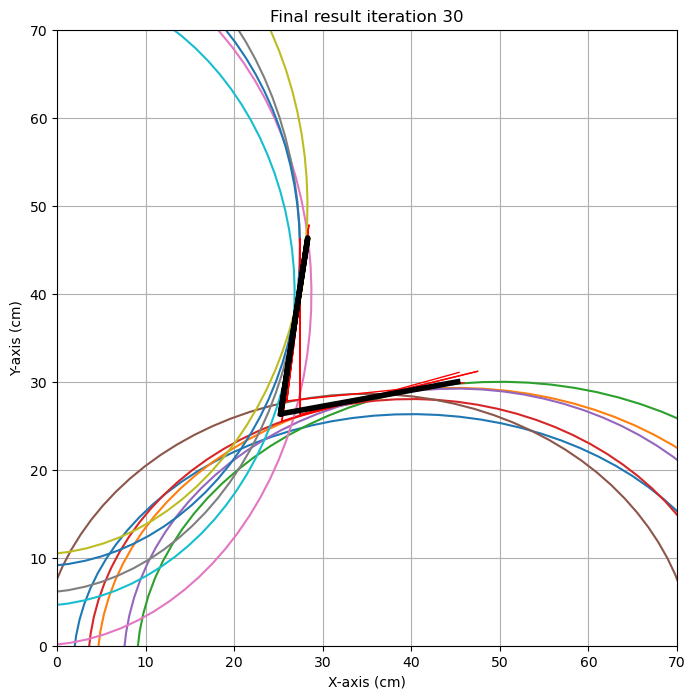

{'alpha': 10.328829418007771, 'alpha_eps': 5.183011646757965, 'beta': 8.73228423981328, 'beta_eps': 8.842027203849415, 'x0': 25.234470983348462, 'x0_eps': 2.2363391074850867, 'y0': 26.34781555252716, 'y0_eps': 1.4748116182916924}
locatie 1 
x0 target is : 20.0. Gevonden waarde: 29.0 cm met een standaardafwijking van 3.2 cm 
y0 target is : 22.7. Gevonden waarde: 27.5 cm met een standaardafwijking van 3.7 cm 
alpha target is : 19.0. Gevonden waarde: 16.9 graden met een standaardafwijking van 13.7 graad 
beta target is : 20.0. Gevonden waarde: 5.0 graden met een standaardafwijking van 13.3 graad 

locatie 2 
x0 target is : 20.0. Gevonden waarde: 25.2 cm met een standaardafwijking van 2.2 cm 
y0 target is : 22.7. Gevonden waarde: 26.3 cm met een standaardafwijking van 1.5 cm 
alpha target is : 19.0. Gevonden waarde: 10.3 graden met een standaardafwijking van 5.2 graad 
beta target is : 20.0. Gevonden waarde: 8.7 graden met een standaardafwijking van 8.8 graad 



In [12]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0':20,
                    'y0':22.7,
                    'alpha' : 19,
                    'beta' : 20},
           'locatie 2':{'x0':20,
                    'y0':22.7,
                    'alpha' : 19,
                    'beta' : 20}
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #voor locatie 1 ITERATIE 3!!, zie uitleg hierboven
    [15,0,65,0,76.3],
    [20,0,70,0,80.9],
    #[10,0,60,0,-],
    [25,0,75,0,82],
    [0,15,0,65,80],
    [0,20,0,70,78],
    #[0,10,0,60,-]
    [0,25,0,75,79.3]
    ]),
    #voor locatie 2 ITERATIE 4!!, zie uitleg hierboven, de -2.5 is de systematische fout door de meetopstelling achter de liniaal te zetten ipv erop
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [15,-2.5,65,-2.5,76.3],
    [20,-2.5,70,-2.5,80.9],
    #[10,0,60,0,-],
    [25,-2.5,75,-2.5,82],
    [20,-2.5,60,-2.5,73],
    [25,-2.5,65,-2.5,75],
    [15,-2.5,55,-2.5,74],
    [-2.5,15,-2.5,65,80],
    [-2.5,20,-2.5,70,78],
    #[0,10,0,60,-]
    [-2.5,25,-2.5,75,79.3],
    [-2.5,20,-2.5,60,71],
    [-2.5,25,-2.5,65,72],
    #[0,15,0,55,-]
    #extra metingen, moest van TA voor betere nauwkeurigheid, gaf slechter resultaat
    #[0,5,0,45,-],
    #[0,10,0,45,],
    #[0,20,0,50,66],
    #[0,25,0,50,60],
    #[0,25,0,45,57]
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

**Afmetingen van het karton klopten niet, dus dat hebben we nu aangepast.**

Iteratie 5 om meer verspreiding in metingen te krijgen door door terug gaan naar B(30,0)O(45,0) 
Figuur: ![Alt](iteratie_5.jpeg)

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

test locatie
Running the imaging algorithm with the following data:
    xs  ys  xr  yr   R
0   15   0  65   0  88
1   20   0  70   0  90
2   10   0  60   0  90
3   30   0  45   0  72
4   35   0  50   0  73
5   25   0  40   0  78
6   25   0  55   0  77
7    0  15   0  65  80
8    0  20   0  70  79
9    0  10   0  60  77
10   0  30   0  45  53
11   0  35   0  50  54
12   0  25   0  41  56
13   0  25   0  55  63


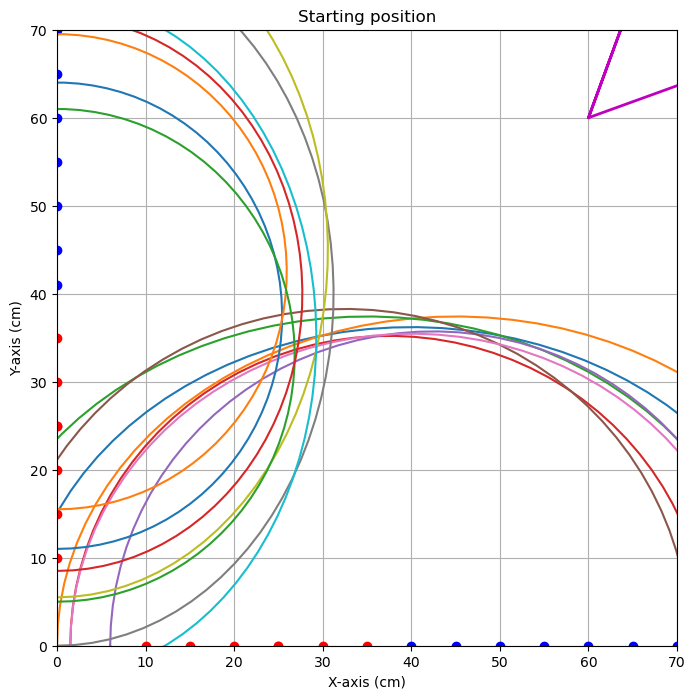


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=64.852


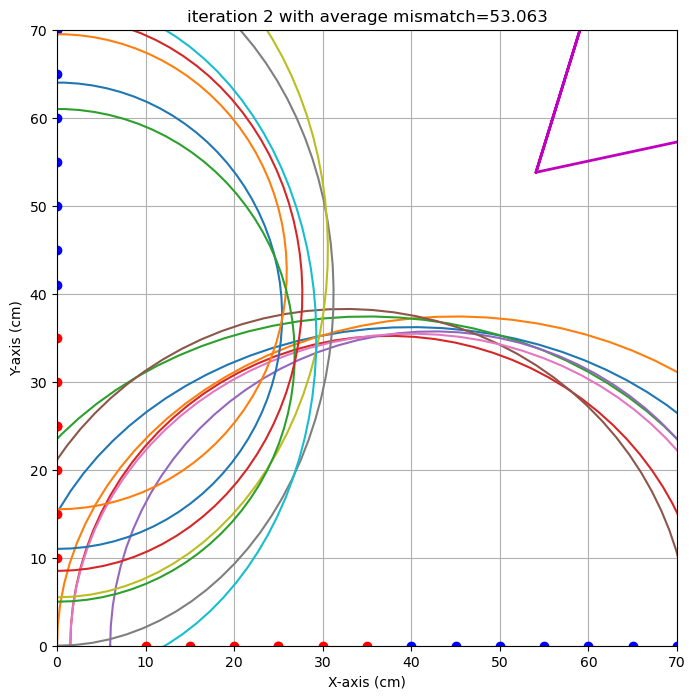

end iteration 2 with average mismatch=53.063


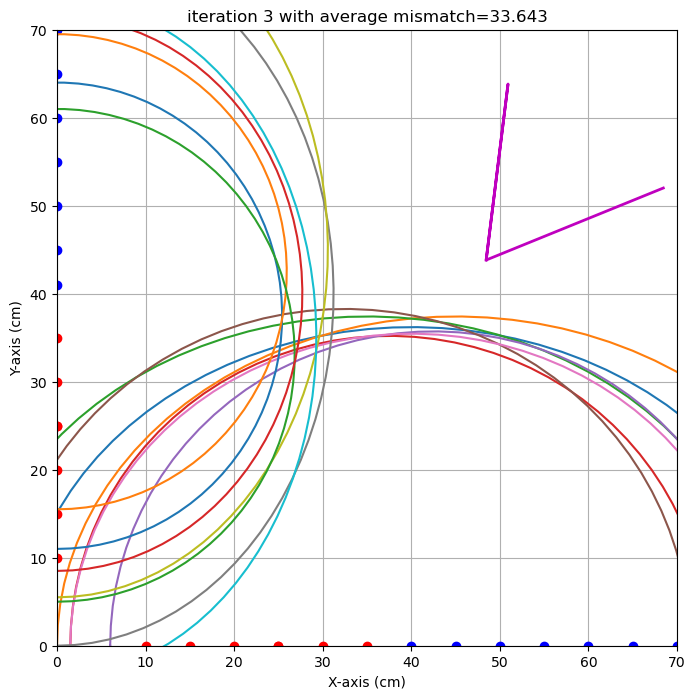

end iteration 3 with average mismatch=33.643


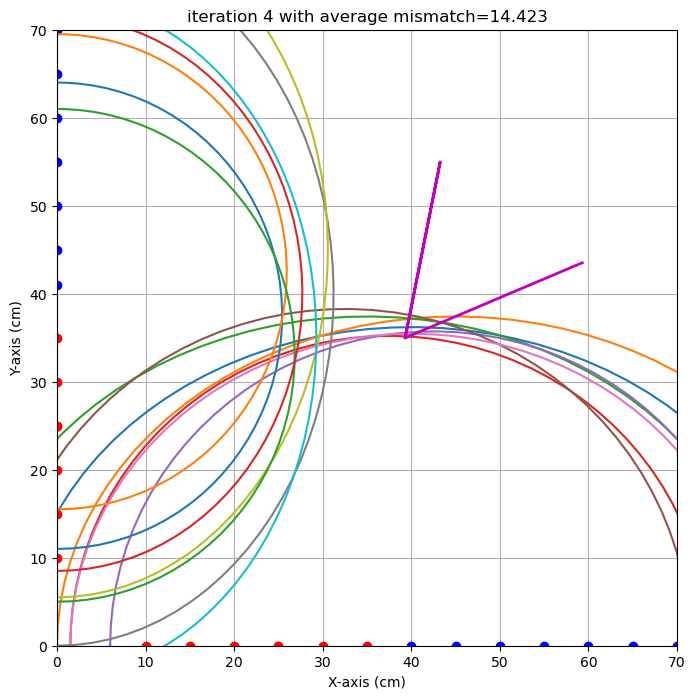

end iteration 4 with average mismatch=14.423


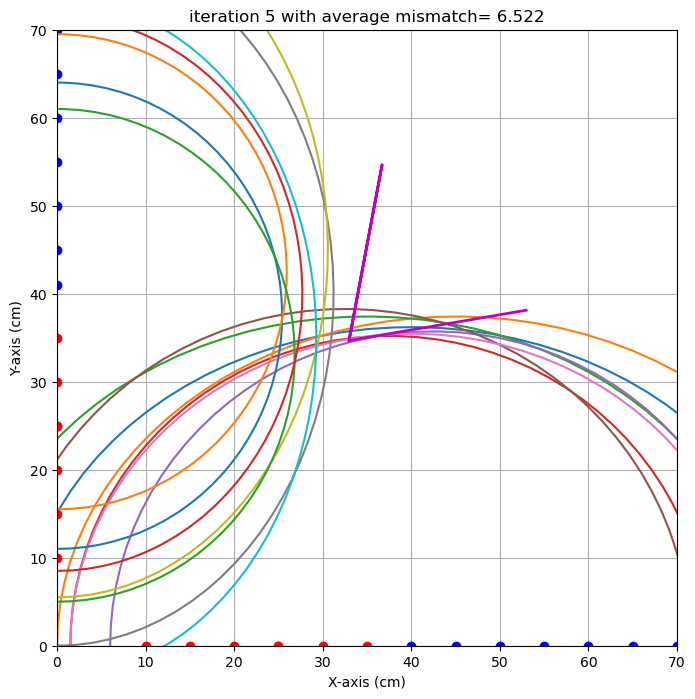

end iteration 5 with average mismatch= 6.522


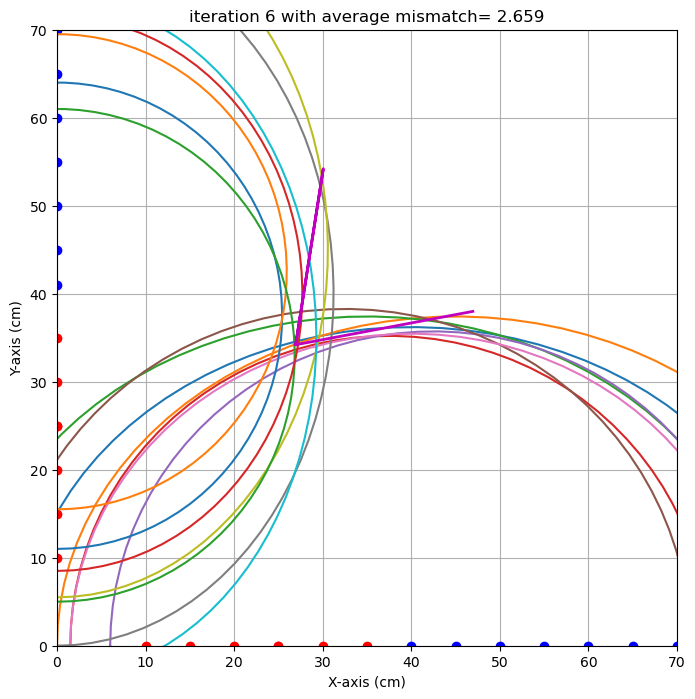

end iteration 6 with average mismatch= 2.659
end iteration 7 with average mismatch= 2.425
end iteration 8 with average mismatch= 2.424
end iteration 9 with average mismatch= 2.423
end iteration 10 with average mismatch= 2.423
end iteration 11 with average mismatch= 2.380
end iteration 12 with average mismatch= 2.380
end iteration 13 with average mismatch= 2.380
end iteration 14 with average mismatch= 2.379
end iteration 15 with average mismatch= 2.377
end iteration 16 with average mismatch= 2.374
end iteration 17 with average mismatch= 2.368
end iteration 18 with average mismatch= 2.366
end iteration 19 with average mismatch= 2.365
end iteration 20 with average mismatch= 2.365
end iteration 21 with average mismatch= 2.365
end iteration 22 with average mismatch= 2.365
end iteration 23 with average mismatch= 2.365
end iteration 24 with average mismatch= 2.365
end iteration 25 with average mismatch= 2.365
end iteration 26 with average mismatch= 2.365
end iteration 27 with average mismatch

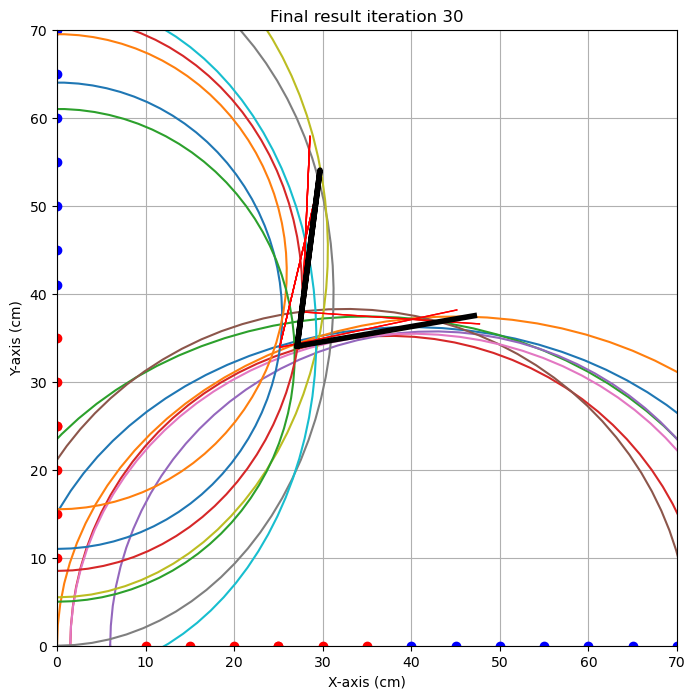

{'alpha': 9.805574730692294, 'alpha_eps': 13.680151910615306, 'beta': 7.354250861469509, 'beta_eps': 5.922207827630483, 'x0': 27.111568048136427, 'x0_eps': 1.9819908202250431, 'y0': 34.043573988365495, 'y0_eps': 3.8827515403678277}
test locatie 
x0 target is : 24.2. Gevonden waarde: 27.1 cm met een standaardafwijking van 2.0 cm 
y0 target is : 32.5. Gevonden waarde: 34.0 cm met een standaardafwijking van 3.9 cm 
alpha target is : 12.0. Gevonden waarde: 9.8 graden met een standaardafwijking van 13.7 graad 
beta target is : 2.0. Gevonden waarde: 7.4 graden met een standaardafwijking van 5.9 graad 



In [13]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0': 24.2 ,
                    'y0': 32.5 ,
                    'alpha' : 12 ,
                    'beta' : 2 
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
                    [15,0,65,0,88],
                    [20,0,70,0,90],
                    [10,0,60,0,90],
                    [30,0,45,0,72],
                    [35,0,50,0,73],
                    [25,0,40,0,78],
                    [25,0,55,0,77],
                    [0,15,0,65,80],
                    [0,20,0,70,79],
                    [0,10,0,60,77],
                    [0,30,0,45,53],
                    [0,35,0,50,54],
                    [0,25,0,41,56],
                    [0,25,0,55,63],
                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 11: Leerdoelen.


#### algoritme Annet
<img src="Algoritme_Annet.jpeg" width="400">

#### algoritme Daantje
<img src="Algoritme_Daantje.jpeg" width="400">

#### algoritme Annelinde
<img src="Algoritme_Annelinde.jpeg" width="400">

Iteratie 1
Door de hoek in het karton kwamen we er achter dat het uitsluiten van regio's niet goed werkt. Het karton kan namelijk wel in een regio staan, maar niet gezien worden. Daarom houden we de bron nu constant in het midden en verschuiven de bron over een as totdat we 2 metingen op die as hebben. Na proberen gaf ook dit vaak geen metingen op een as.

Figuur: ![Alt](iteratie_1.jpeg)



Iteratie 2

De volgende iteratie was om zowel de bron als de ontvanger te verschuiven van buiten naar binnen. Bij een goede meting verschuiven we zowel de bron als ontvanger 5 cm naar links of rechts. Dit hebben we hieronder bij locatie 2 gedaan.



Iteratie 3

De vorige iteratie met beide bronnen naar binnen verschuiven lijkt te werken. Om het resultaat nauwkeuriger te maken, doen we nu 3 goede metingen per as.

Figuur: ![Alt](iteratie_2.jpeg)



Iteratie 4: Meer metingen per kant voor betere nauwkeurigheid als er metingen over zijn

Figuur: ![Alt](iteratie_3.jpeg)


**Afmetingen van het karton klopten niet, dus dat hebben we nu aangepast.**

Iteratie 5 om meer verspreiding in metingen te krijgen door door terug gaan naar B(30,0)O(45,0) 
Figuur: ![Alt](iteratie_5.jpeg)